[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/02-tumor-growth.ipynb)

# 02 — Tumor Growth: From Logistic Models to Spatial Simulations

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) — 2025-02-23_<br>
_Updated: 2026-02-19_  (Cursor 2.5.17 with Claude Opus 4.6) <br>
_Updated: 2026-02-20_  (Cursor 2.5.20 with Claude Opus 4.6) - saved notebook to .pdf<br>
_Updated: 2026-02-28_  (Ubuntu 24.04, Cursor 2.5.26 with Claude Opus 4.6) - Testing

---


## 1. Motivation & Learning Objectives

### Why study tumor growth modeling?

**Cancer** is the second leading cause of death worldwide, claiming nearly 10 million lives each year. Unlike many diseases that strike suddenly, most solid tumors grow over months to years — passing through stages of initiation, promotion, progression, and metastasis. This temporal evolution means that **mathematical modeling** can play a crucial role: if we can describe and predict how a tumor grows, we can make better decisions about *when* to intervene, *how aggressively* to treat, and *what outcome* to expect.

Tumor growth modeling sits at the intersection of **biology**, **mathematics**, and **medicine**. At its simplest, a tumor growth model is an ordinary differential equation (ODE) with just two parameters — the growth rate and carrying capacity. At its most complex, it is a system of coupled partial differential equations (PDEs) capturing spatial diffusion, nutrient transport, angiogenesis, immune interactions, and mechanical forces. This spectrum of complexity makes tumor growth an ideal case study for **computational medicine**: it illustrates how progressively richer mathematical descriptions capture progressively more biological reality.

### What you will learn

In this notebook you will:

1. **Understand** the biological basis of tumor growth — what drives cell proliferation, nutrient limitation, necrosis, and angiogenesis
2. **Appreciate** the historical context — from Benjamin Gompertz's 1825 actuarial curves to modern PDE-based spatial models
3. **Master** the simplest tumor growth model — the **two-parameter logistic growth model** — and understand its analytical solution
4. **Implement** a logistic growth case study in Python and visualize the characteristic sigmoid growth curve
5. **Explore** increasingly complex spatial models — 1D and 2D reaction-diffusion equations that capture nutrient-limited growth
6. **Analyze** tumor compartments (enhancing tumor, necrotic core) and their evolution over time
7. **Simulate** tumor angiogenesis — the formation of new blood vessels driven by tumor-secreted growth factors
8. **Connect** mathematical models to clinical applications — treatment planning, imaging biomarkers, and personalized medicine

## 2. Historical Context: From Actuarial Tables to Computational Oncology

### The long quest to describe growth mathematically

The mathematical description of biological growth has a surprisingly rich history that predates modern oncology by more than a century. Key milestones in the development of tumor growth models include:

| Year | Milestone | Key figures |
|------|-----------|-------------|
| 1798 | Exponential growth model for populations | Thomas Robert **Malthus** |
| 1825 | Gompertz growth law — exponentially decelerating growth | Benjamin **Gompertz** |
| 1838 | Logistic growth equation — growth with carrying capacity | Pierre-François **Verhulst** |
| 1920s–30s | Application of Gompertz and logistic models to tumor growth | Various radiobiologists |
| 1957 | Von Bertalanffy growth model applied to tumors | Ludwig **von Bertalanffy** |
| 1964 | Laird's landmark study fitting Gompertz curves to experimental tumor data | Anna Kane **Laird** |
| 1970s | Norton-Simon hypothesis — tumor growth rate determines chemotherapy response | Larry **Norton** & Richard **Simon** |
| 1972 | Greenspan's spheroid model — first spatial model with necrotic core | H. P. **Greenspan** |
| 1985 | Folkman's angiogenesis hypothesis fully articulated | Judah **Folkman** |
| 1996 | Reaction-diffusion models of avascular tumor growth | Byrne & Chaplain |
| 2000s | Multi-scale models integrating molecular, cellular, and tissue scales | Anderson, Chaplain, Cristini et al. |
| 2010s–present | Patient-specific models calibrated from medical imaging (MRI, PET) | Swanson, Hormuth, Yankeelov et al. |

### Benjamin Gompertz and the law of mortality

In 1825, the British actuary **Benjamin Gompertz** published a paper titled *"On the Nature of the Function Expressive of the Law of Human Mortality"* in the *Philosophical Transactions of the Royal Society*. His goal was to describe how mortality rates increase with age, but the mathematical function he derived — characterized by an exponentially *decreasing* growth rate — turned out to describe tumor growth remarkably well.

> *"It is possible that death may be the consequence of two generally co-existing causes; the one, chance, without previous disposition to death or deterioration; the other, a deterioration, or an increased inability to withstand destruction."* — Benjamin Gompertz (1825)

Nearly 140 years later, Anna Kane Laird (1964) demonstrated that the Gompertz function provided excellent fits to experimental tumor growth data across many tumor types. This connection between 19th-century actuarial mathematics and 20th-century oncology is one of the beautiful surprises in the history of mathematical biology.

### Pierre-François Verhulst and the logistic equation

In 1838, the Belgian mathematician **Pierre-François Verhulst** introduced the **logistic equation** as an improvement over Malthus's exponential growth model. Verhulst recognized that populations cannot grow indefinitely — they are limited by resources, space, and competition. He proposed that the per-capita growth rate decreases linearly with population size, leading to the equation:

$$\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right)$$

where $r$ is the intrinsic growth rate and $K$ is the **carrying capacity** — the maximum population the environment can sustain. This elegantly simple model, with just **two parameters**, captures the essential transition from rapid early growth to saturation — precisely the behavior observed in many tumors.

### From ODE models to spatial PDE models

While ODE models like the logistic and Gompertz equations capture the overall *temporal* dynamics of tumor growth (how total tumor volume changes over time), they say nothing about *spatial* structure — the shape of the tumor, the distribution of nutrients, the formation of necrotic cores, or the invasion of surrounding tissue.

Beginning in the 1970s with Greenspan's pioneering spheroid models, researchers developed **partial differential equation (PDE)** models that treat the tumor as a spatially distributed object. These reaction-diffusion models track how tumor cell density and nutrient concentrations vary across space and time, capturing phenomena such as:
- **Diffusion-limited growth** — cells at the tumor periphery proliferate while interior cells starve
- **Necrotic core formation** — central regions die due to nutrient depletion
- **Angiogenesis** — tumors recruit new blood vessels to sustain their growth
- **Invasion** — tumor cells migrate into surrounding healthy tissue

In [1]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %matplotlib inline
    import urllib.request, os
    os.makedirs('../assets', exist_ok=True)
    _base = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab5-Comp-Mod/assets/'
    for f in ['verhulst-portrait.jpg', 'tumor-angiogenesis.png', 'tumor-microenvironment.jpg', 'logistic-curve.png']:
        if not os.path.exists(f'../assets/{f}'):
            urllib.request.urlretrieve(_base + f, f'../assets/{f}')
else:
    %matplotlib inline

In [2]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %matplotlib inline
    import urllib.request, os
    os.makedirs('../assets', exist_ok=True)
    _base = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab5-Comp-Mod/assets/'
    for f in ['verhulst-portrait.jpg', 'tumor-angiogenesis.png',
              'tumor-microenvironment.jpg', 'logistic-curve.png']:
        if not os.path.exists(f'../assets/{f}'):
            urllib.request.urlretrieve(_base + f, f'../assets/{f}')
else:
    %matplotlib inline

In [3]:
from IPython.display import display, HTML

# Display historical images (local copies in assets/)
display(HTML('''
<figure style="text-align:center; margin: 20px 0;">
<img src="../assets/verhulst-portrait.jpg"
     alt="Pierre-François Verhulst" width="250"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 1.</b> Pierre-François Verhulst (1804–1849), the Belgian mathematician who introduced
the logistic equation in 1838. His model of population growth with a carrying capacity
became one of the most widely used models in mathematical biology — including tumor growth.
<br/><i>Source: Wikimedia Commons (public domain).</i>
</figcaption>
</figure>
'''))

display(HTML('''
<figure style="text-align:center; margin: 20px 0;">
<img src="../assets/tumor-angiogenesis.png"
     alt="Tumor angiogenesis and the angiogenic switch" width="800"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 2.</b> Tumor angiogenesis and the angiogenic switch — the transition by which tumors
stimulate the growth of new blood vessels to sustain their nutrient supply and grow beyond
the diffusion limit. Based on concepts from Judah Folkman and Gabriele Bergers.
<br/><i>Source: Wikimedia Commons, by Mjeltsch (CC BY-SA 4.0).</i>
</figcaption>
</figure>
'''))

## 3. Scientific and Clinical Implications

Understanding tumor growth through mathematical models has far-reaching consequences in both basic science and clinical medicine:

### Cancer Treatment Planning
- **Chemotherapy scheduling**: The **Norton-Simon hypothesis** (1970s) showed that tumor response to chemotherapy depends on the growth *rate* at the time of treatment — not just the tumor size. Tumors growing faster (on the steep part of the sigmoid) respond better. This insight, derived directly from Gompertz growth models, led to **dose-dense chemotherapy** protocols that have improved survival in breast cancer and lymphoma.
- **Radiation therapy fractionation**: Models of tumor repopulation between radiation fractions guide the choice of dose per fraction and overall treatment time.
- **Surgical timing**: Growth models help estimate the "age" of a tumor and predict its size at the time of planned surgery.

### Medical Imaging & Biomarkers
- **Tumor doubling time** — estimated from serial imaging (CT, MRI) — is a key prognostic biomarker. Growth models provide the mathematical framework for extracting doubling times from imaging data.
- **Patient-specific growth models** calibrated from longitudinal MRI scans can predict future tumor extent, informing surgical margins and radiation target volumes.
- **Response assessment**: Measuring changes in tumor growth parameters before and during treatment can provide early indicators of therapeutic response (e.g., RECIST criteria, volumetric analysis).

### Personalized / Precision Medicine
- By fitting growth models to individual patient data, clinicians can estimate patient-specific growth rates and carrying capacities, enabling **personalized treatment optimization**.
- Computational models can simulate "virtual clinical trials" — testing different treatment strategies *in silico* before committing to a treatment plan.

### Drug Development
- Tumor growth models are routinely used in **preclinical and clinical pharmacology** to describe tumor volume changes in xenograft studies and clinical trials.
- The logistic and Gompertz models, in particular, are workhorses of **pharmacodynamic modeling** — they describe the baseline tumor growth that drugs must overcome.

### Understanding Fundamental Biology
- Growth models formalize the conceptual distinction between **exponential** (unlimited) and **sigmoidal** (resource-limited) growth, connecting cell biology to ecological concepts like carrying capacity.
- Spatial PDE models illuminate how **microenvironment** (nutrients, oxygen, acidity) shapes tumor morphology and heterogeneity — key factors in treatment resistance.

## 4. The Biology of Tumor Growth

### What is a tumor?

A **tumor** (or neoplasm) is an abnormal mass of tissue that arises when cell proliferation exceeds cell death. Tumors can be **benign** (localized, non-invasive) or **malignant** (cancer — capable of invasion and metastasis). The growth of a solid tumor is governed by a complex interplay of biological processes:

### Key biological processes

| Process | Description | Effect on growth |
|---------|-------------|-----------------|
| **Cell proliferation** | Tumor cells divide, often faster than normal cells, driven by oncogene activation and loss of tumor suppressors | Drives exponential-like early growth |
| **Apoptosis** | Programmed cell death; often impaired in cancer cells | Reduced cell loss → net growth |
| **Nutrient supply** | Cells require oxygen and glucose; delivery depends on proximity to blood vessels | Limits growth in avascular tumors; drives Gompertzian deceleration |
| **Necrosis** | Cell death due to nutrient deprivation, especially in the tumor interior | Creates necrotic core; characteristic of advanced tumors |
| **Angiogenesis** | Tumor cells secrete VEGF and other factors to stimulate new blood vessel formation | Enables continued growth beyond ~1–2 mm diameter |
| **Immune response** | The immune system can recognize and kill tumor cells (immunosurveillance) | Slows growth; basis of immunotherapy |
| **Invasion & metastasis** | Tumor cells break through basement membranes and spread to distant organs | Not captured by simple growth models; requires spatial/agent-based models |

### The growth phases of a solid tumor

A typical solid tumor passes through several growth phases:

1. **Avascular phase** (diameter < 1–2 mm): The tumor grows as a compact mass, relying on diffusion for nutrient delivery. Growth is initially exponential but slows as interior cells become nutrient-starved. A **necrotic core** may develop.

2. **Angiogenic switch**: When the tumor reaches a critical size (~1–2 mm), hypoxic cells secrete **vascular endothelial growth factor (VEGF)** and other angiogenic signals, triggering the growth of new blood vessels toward the tumor.

3. **Vascular phase**: With a blood supply established, the tumor can grow much larger. The balance between proliferation at the well-vascularized periphery and necrosis in the interior creates characteristic spatial heterogeneity.

4. **Invasion and metastasis**: Some tumor cells acquire the ability to invade surrounding tissue and enter the bloodstream, establishing secondary tumors at distant sites.

> *"A tumor is not merely a homogeneous ball of identical cells, but a complex ecosystem with spatial structure, genetic heterogeneity, and dynamic interactions with its microenvironment."* — Douglas Hanahan & Robert Weinberg (2011)

In [4]:
from IPython.display import display, HTML

# Display tumor biology illustrations (local copies in assets/)
display(HTML('''
<figure style="text-align:center; margin: 20px 0;">
<img src="../assets/tumor-microenvironment.jpg"
     alt="Tumor microenvironment" width="800"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 3a.</b> The tumor microenvironment — a complex ecosystem of tumor cells and immune cells.
During the <i>elimination phase</i> (left), immune effector cells recognize and destroy tumor cells.
During the <i>escape phase</i> (right), less immunogenic tumor cells evade immunosurveillance.
<br/><i>Source: Frontiers in Oncology / Wikimedia Commons (CC BY 3.0).</i>
</figcaption>
</figure>
'''))

display(HTML('''
<figure style="text-align:center; margin: 20px 0;">
<img src="../assets/logistic-curve.png"
     alt="Logistic sigmoid curve" width="400"/>
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 3b.</b> The logistic sigmoid function — the characteristic S-shaped curve that describes
growth with a carrying capacity. This shape arises naturally when the per-capita growth rate
decreases linearly with population size, and is the foundation of the simplest tumor growth model.
<br/><i>Source: Wikimedia Commons (public domain, by Qef).</i>
</figcaption>
</figure>
'''))

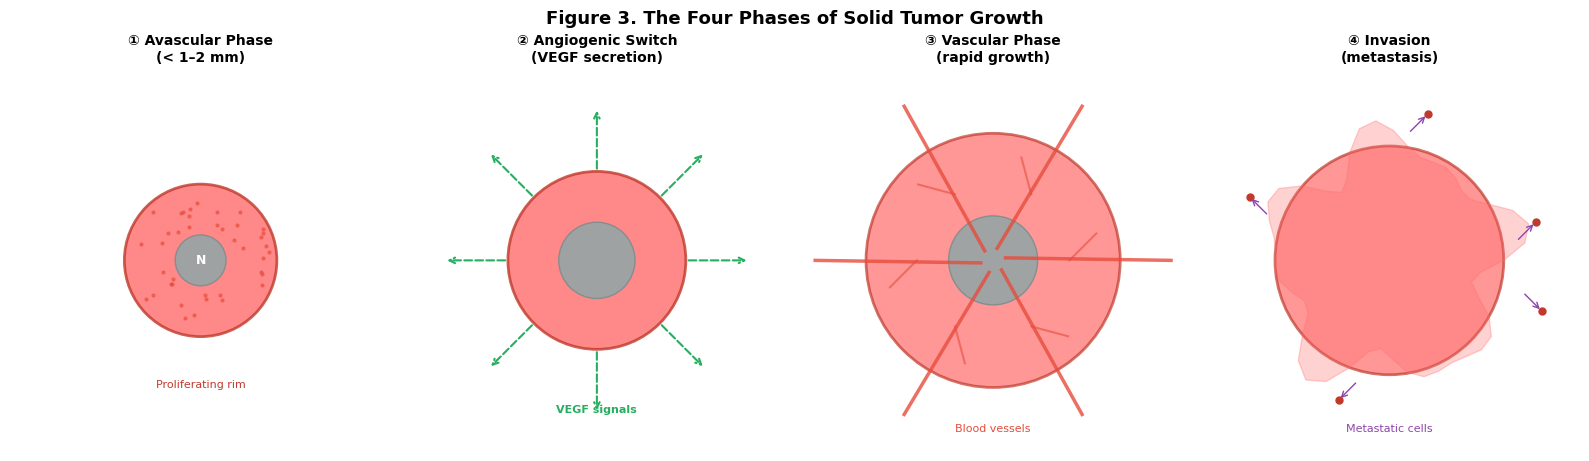

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib.collections import PatchCollection

# --- Programmatic illustration: Tumor growth phases ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

titles = [
    '① Avascular Phase\n(< 1–2 mm)',
    '② Angiogenic Switch\n(VEGF secretion)',
    '③ Vascular Phase\n(rapid growth)',
    '④ Invasion\n(metastasis)'
]

for ax, title in zip(axes, titles):
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')

# Phase 1: Small avascular tumor with necrotic core
ax = axes[0]
tumor = Circle((0, 0), 0.6, facecolor='#FF6B6B', edgecolor='#C0392B', linewidth=2, alpha=0.8)
ax.add_patch(tumor)
necrotic = Circle((0, 0), 0.2, facecolor='#95A5A6', edgecolor='#7F8C8D', linewidth=1, alpha=0.9)
ax.add_patch(necrotic)
ax.text(0, -1.0, 'Proliferating rim', fontsize=8, ha='center', color='#C0392B')
ax.text(0, 0, 'N', fontsize=9, ha='center', va='center', color='white', fontweight='bold')
# Add small dots for cells
np.random.seed(42)
for _ in range(40):
    angle = np.random.uniform(0, 2*np.pi)
    r = np.random.uniform(0.25, 0.55)
    ax.plot(r*np.cos(angle), r*np.sin(angle), 'o', color='#E74C3C', markersize=2, alpha=0.6)

# Phase 2: Angiogenic switch - tumor secreting VEGF
ax = axes[1]
tumor = Circle((0, 0), 0.7, facecolor='#FF6B6B', edgecolor='#C0392B', linewidth=2, alpha=0.8)
ax.add_patch(tumor)
necrotic = Circle((0, 0), 0.3, facecolor='#95A5A6', edgecolor='#7F8C8D', linewidth=1, alpha=0.9)
ax.add_patch(necrotic)
# VEGF signals (wavy arrows going outward)
for angle in np.linspace(0, 2*np.pi, 8, endpoint=False):
    x0 = 0.7 * np.cos(angle)
    y0 = 0.7 * np.sin(angle)
    x1 = 1.2 * np.cos(angle)
    y1 = 1.2 * np.sin(angle)
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5, ls='--'))
ax.text(0, -1.2, 'VEGF signals', fontsize=8, ha='center', color='#27AE60', fontweight='bold')

# Phase 3: Vascularized tumor with blood vessels
ax = axes[2]
tumor = Circle((0, 0), 1.0, facecolor='#FF6B6B', edgecolor='#C0392B', linewidth=2, alpha=0.7)
ax.add_patch(tumor)
necrotic = Circle((0, 0), 0.35, facecolor='#95A5A6', edgecolor='#7F8C8D', linewidth=1, alpha=0.9)
ax.add_patch(necrotic)
# Blood vessels (red lines penetrating tumor)
vessel_angles = [0, np.pi/3, 2*np.pi/3, np.pi, 4*np.pi/3, 5*np.pi/3]
for angle in vessel_angles:
    x_out = 1.4 * np.cos(angle)
    y_out = 1.4 * np.sin(angle)
    ax.plot([x_out, 0.1*np.cos(angle+0.2)], [y_out, 0.1*np.sin(angle+0.2)],
            color='#E74C3C', linewidth=2.5, alpha=0.8)
    # Branch points
    mid_x = 0.6 * np.cos(angle)
    mid_y = 0.6 * np.sin(angle)
    branch_angle = angle + np.pi/4
    ax.plot([mid_x, mid_x + 0.3*np.cos(branch_angle)],
            [mid_y, mid_y + 0.3*np.sin(branch_angle)],
            color='#E74C3C', linewidth=1.5, alpha=0.6)
ax.text(0, -1.35, 'Blood vessels', fontsize=8, ha='center', color='#E74C3C')

# Phase 4: Invasion with cells breaking away
ax = axes[3]
tumor = Circle((0, 0), 0.9, facecolor='#FF6B6B', edgecolor='#C0392B', linewidth=2, alpha=0.7)
ax.add_patch(tumor)
# Irregular invasion front
invasion_angles = np.linspace(0, 2*np.pi, 50)
invasion_r = 0.9 + 0.15 * np.sin(5*invasion_angles) + 0.1 * np.sin(8*invasion_angles)
ax.fill(invasion_r*np.cos(invasion_angles), invasion_r*np.sin(invasion_angles),
        color='#FF6B6B', alpha=0.3)
# Escaping cells (metastasis)
escape_positions = [(1.15, 0.3), (1.2, -0.4), (-1.1, 0.5), (0.3, 1.15), (-0.4, -1.1)]
for (ex, ey) in escape_positions:
    ax.plot(ex, ey, 'o', color='#C0392B', markersize=5)
    # Arrow from tumor edge toward escaping cell
    dx = ex - 0.7*(ex/max(abs(ex), 0.01))
    dy = ey - 0.7*(ey/max(abs(ey), 0.01))
    ax.annotate('', xy=(ex, ey), xytext=(ex - 0.15*np.sign(ex), ey - 0.15*np.sign(ey)),
                arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=1))
ax.text(0, -1.35, 'Metastatic cells', fontsize=8, ha='center', color='#8E44AD')

plt.suptitle('Figure 3. The Four Phases of Solid Tumor Growth', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/fig03-tumor-growth-phases.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Overview of Tumor Growth Models: From Simple to Complex

Mathematical models of tumor growth span a wide range of complexity. The table below summarizes the most important classes, from the simplest ODE models to multi-scale PDE systems:

| Model | Type | Parameters | Key equation | What it captures |
|-------|------|-----------|--------------|-----------------|
| **Exponential** | ODE | 1 ($r$) | $\frac{dN}{dt} = rN$ | Unlimited early growth |
| **Logistic** (Verhulst) | ODE | 2 ($r, K$) | $\frac{dN}{dt} = rN\left(1-\frac{N}{K}\right)$ | Growth saturation at carrying capacity |
| **Gompertz** | ODE | 2 ($a, b$) | $\frac{dN}{dt} = -aN\ln\left(\frac{N}{K}\right)$ | Exponentially decelerating growth rate |
| **Von Bertalanffy** | ODE | 2–3 | $\frac{dN}{dt} = \eta N^{2/3} - \mu N$ | Surface-driven growth vs. volume-driven decay |
| **Generalized logistic** | ODE | 3+ | $\frac{dN}{dt} = rN\left[1-\left(\frac{N}{K}\right)^\nu\right]$ | Flexible sigmoid shape |
| **Reaction-diffusion** | PDE | 5+ | $\frac{\partial u}{\partial t} = D\nabla^2 u + f(u,v)$ | Spatial spread + nutrient coupling |
| **Angiogenesis models** | PDE + rules | 10+ | Coupled PDEs for cells, nutrients, VEGF, vessels | Vascularization and spatial heterogeneity |
| **Multi-scale** | Hybrid | Many | Agent-based + continuum | Genetic heterogeneity, immune interactions |

### The model hierarchy — a key concept

A central idea in computational medicine is the **model hierarchy**: starting with the simplest model that captures the essential behavior, then adding complexity only as needed. For tumor growth:

1. **Start with the logistic model** (2 parameters) — captures the sigmoid growth curve
2. **Add spatial diffusion** (reaction-diffusion PDE) — captures tumor shape and nutrient gradients
3. **Add angiogenesis** — captures the vascular phase and blood vessel formation
4. **Add immune interactions, drug response, genetic heterogeneity** — for treatment modeling

This "bottom-up" approach is both pedagogically sound and scientifically productive: each level of complexity introduces new phenomena while building on the intuition developed at simpler levels.

> *"All models are wrong, but some are useful."* — George E. P. Box

In this notebook, we begin with the logistic model and progress through the full hierarchy.

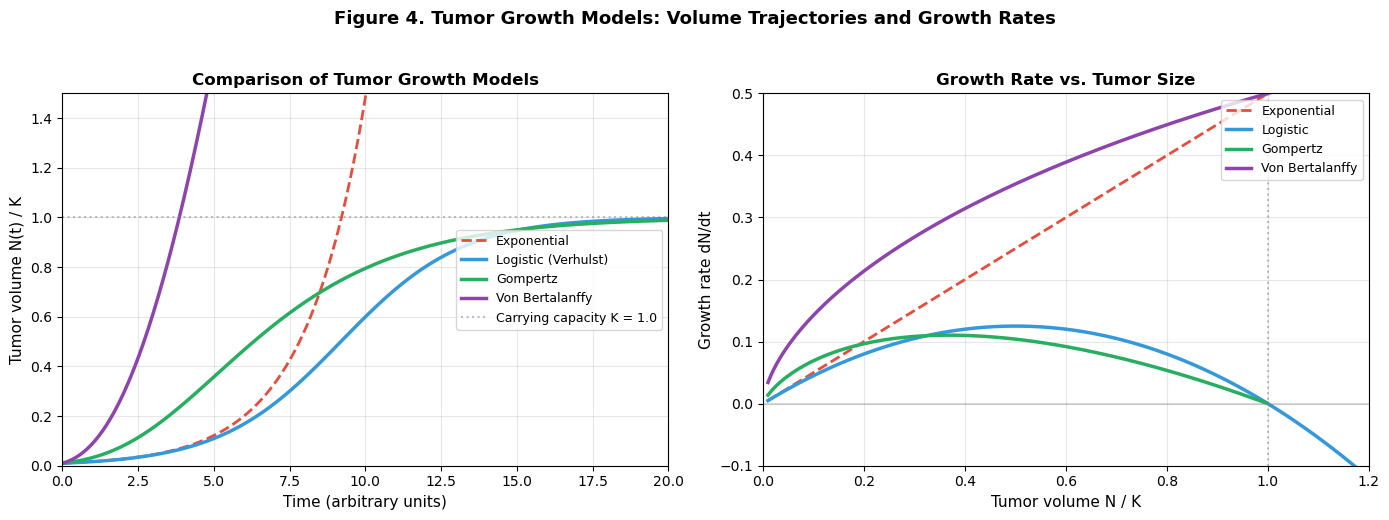

Key observations:
• Exponential growth: unlimited, unrealistic for long times — but good approximation for early growth
• Logistic growth: symmetric sigmoid, growth rate peaks at N = K/2
• Gompertz growth: asymmetric sigmoid, faster early growth, slower approach to K
• Von Bertalanffy: surface-area-driven growth vs. volume-driven decay


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# --- Compare different tumor growth models ---

# Common parameters
N0 = 0.01       # Initial tumor volume (fraction of carrying capacity)
K = 1.0          # Carrying capacity (normalized)
r = 0.5          # Growth rate
t = np.linspace(0, 20, 500)

# 1. Exponential growth: dN/dt = r*N
N_exp = N0 * np.exp(r * t)
N_exp_clipped = np.minimum(N_exp, 3.0)  # Clip for visualization

# 2. Logistic growth: dN/dt = r*N*(1 - N/K), analytical solution
N_logistic = K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# 3. Gompertz growth: dN/dt = -a*N*ln(N/K), analytical solution: N(t) = K*exp(ln(N0/K)*exp(-a*t))
a = 0.3  # Gompertz rate parameter
N_gompertz = K * np.exp(np.log(N0 / K) * np.exp(-a * t))

# 4. Von Bertalanffy: dN/dt = eta*N^(2/3) - mu*N (solved numerically)
eta_vb = 0.8
mu_vb = 0.3
def von_bertalanffy(N, t):
    return eta_vb * N**(2.0/3.0) - mu_vb * N
N_vb = odeint(von_bertalanffy, N0, t).flatten()

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: All models compared
ax = axes[0]
ax.plot(t, N_exp_clipped, '--', color='#E74C3C', linewidth=2, label='Exponential')
ax.plot(t, N_logistic, '-', color='#3498DB', linewidth=2.5, label='Logistic (Verhulst)')
ax.plot(t, N_gompertz, '-', color='#27AE60', linewidth=2.5, label='Gompertz')
ax.plot(t, N_vb, '-', color='#8E44AD', linewidth=2.5, label='Von Bertalanffy')
ax.axhline(y=K, color='gray', linestyle=':', alpha=0.5, label=f'Carrying capacity K = {K}')
ax.set_xlabel('Time (arbitrary units)', fontsize=11)
ax.set_ylabel('Tumor volume N(t) / K', fontsize=11)
ax.set_title('Comparison of Tumor Growth Models', fontsize=12, fontweight='bold')
ax.legend(loc='right', fontsize=9)
ax.set_ylim(0, 1.5)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 20)

# Right panel: Growth rates (dN/dt) as a function of N
ax = axes[1]
N_range = np.linspace(0.01, 1.2, 200)
# Exponential rate
rate_exp = r * N_range
# Logistic rate
rate_logistic = r * N_range * (1 - N_range / K)
# Gompertz rate
rate_gompertz = -a * N_range * np.log(N_range / K)
rate_gompertz[N_range > K] = np.nan  # Undefined above K for this form
# Von Bertalanffy rate
rate_vb = eta_vb * N_range**(2.0/3.0) - mu_vb * N_range

ax.plot(N_range, rate_exp, '--', color='#E74C3C', linewidth=2, label='Exponential')
ax.plot(N_range, rate_logistic, '-', color='#3498DB', linewidth=2.5, label='Logistic')
ax.plot(N_range, rate_gompertz, '-', color='#27AE60', linewidth=2.5, label='Gompertz')
ax.plot(N_range, rate_vb, '-', color='#8E44AD', linewidth=2.5, label='Von Bertalanffy')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=K, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Tumor volume N / K', fontsize=11)
ax.set_ylabel('Growth rate dN/dt', fontsize=11)
ax.set_title('Growth Rate vs. Tumor Size', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-0.1, 0.5)
ax.set_xlim(0, 1.2)
ax.grid(True, alpha=0.3)

plt.suptitle('Figure 4. Tumor Growth Models: Volume Trajectories and Growth Rates',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../assets/fig04-growth-model-comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key observations:")
print("• Exponential growth: unlimited, unrealistic for long times — but good approximation for early growth")
print("• Logistic growth: symmetric sigmoid, growth rate peaks at N = K/2")
print("• Gompertz growth: asymmetric sigmoid, faster early growth, slower approach to K")
print("• Von Bertalanffy: surface-area-driven growth vs. volume-driven decay")

## 6. The Logistic Growth Model: A First Case Study

### The two-parameter logistic growth model

The **logistic growth model** is the simplest tumor growth model that captures the essential transition from rapid initial growth to saturation. It requires only **two parameters**:

- $r$ — the **intrinsic growth rate** (units: time$^{-1}$): how fast the tumor grows when it is small
- $K$ — the **carrying capacity** (units: volume or cell count): the maximum size the tumor can reach, limited by nutrient supply, space, and other constraints

#### The differential equation

$$\frac{dN}{dt} = rN\left(1 - \frac{N}{K}\right)$$

where $N(t)$ is the tumor volume (or cell number) at time $t$.

**Interpretation of the terms:**
- The factor $rN$ represents exponential growth — proportional to the current size
- The factor $(1 - N/K)$ is a **growth inhibition** term that reduces the per-capita growth rate as $N$ approaches $K$
- When $N \ll K$: the inhibition term is approximately 1, and growth is nearly exponential ($dN/dt \approx rN$)
- When $N = K/2$: the growth rate is maximal ($dN/dt = rK/4$)  — this is the **inflection point** of the sigmoid
- When $N = K$: the growth rate is zero — the tumor has reached its carrying capacity

#### The analytical solution

The logistic equation has a closed-form solution:

$$N(t) = \frac{K}{1 + \left(\frac{K - N_0}{N_0}\right) e^{-rt}}$$

where $N_0 = N(0)$ is the initial tumor size. This produces the characteristic **S-shaped (sigmoid) curve**.

#### Key properties of the logistic solution

| Property | Value |
|----------|-------|
| Initial growth (small $N$) | Nearly exponential: $N(t) \approx N_0 e^{rt}$ |
| Inflection point (fastest growth) | At $N = K/2$, time $t^* = \frac{1}{r}\ln\left(\frac{K - N_0}{N_0}\right)$ |
| Saturation | $N \to K$ as $t \to \infty$ |
| Doubling time (early phase) | $T_d = \frac{\ln 2}{r}$ |
| Symmetry | The sigmoid is symmetric about the inflection point |

### Why the logistic model is useful for tumors

Despite its simplicity, the logistic model captures several important features of real tumor growth:

1. **Early exponential growth** — consistent with the observation that small tumors grow roughly exponentially
2. **Growth deceleration** — as the tumor outgrows its nutrient supply, growth slows
3. **Plateau / saturation** — tumors do not grow indefinitely; they reach a maximum size determined by the microenvironment
4. **Clinical parameters** — the growth rate $r$ and carrying capacity $K$ can be estimated from serial imaging data

The model's limitations are also instructive: it does not capture spatial heterogeneity, necrosis, angiogenesis, or immune interactions — motivating the more complex models explored later in this notebook.

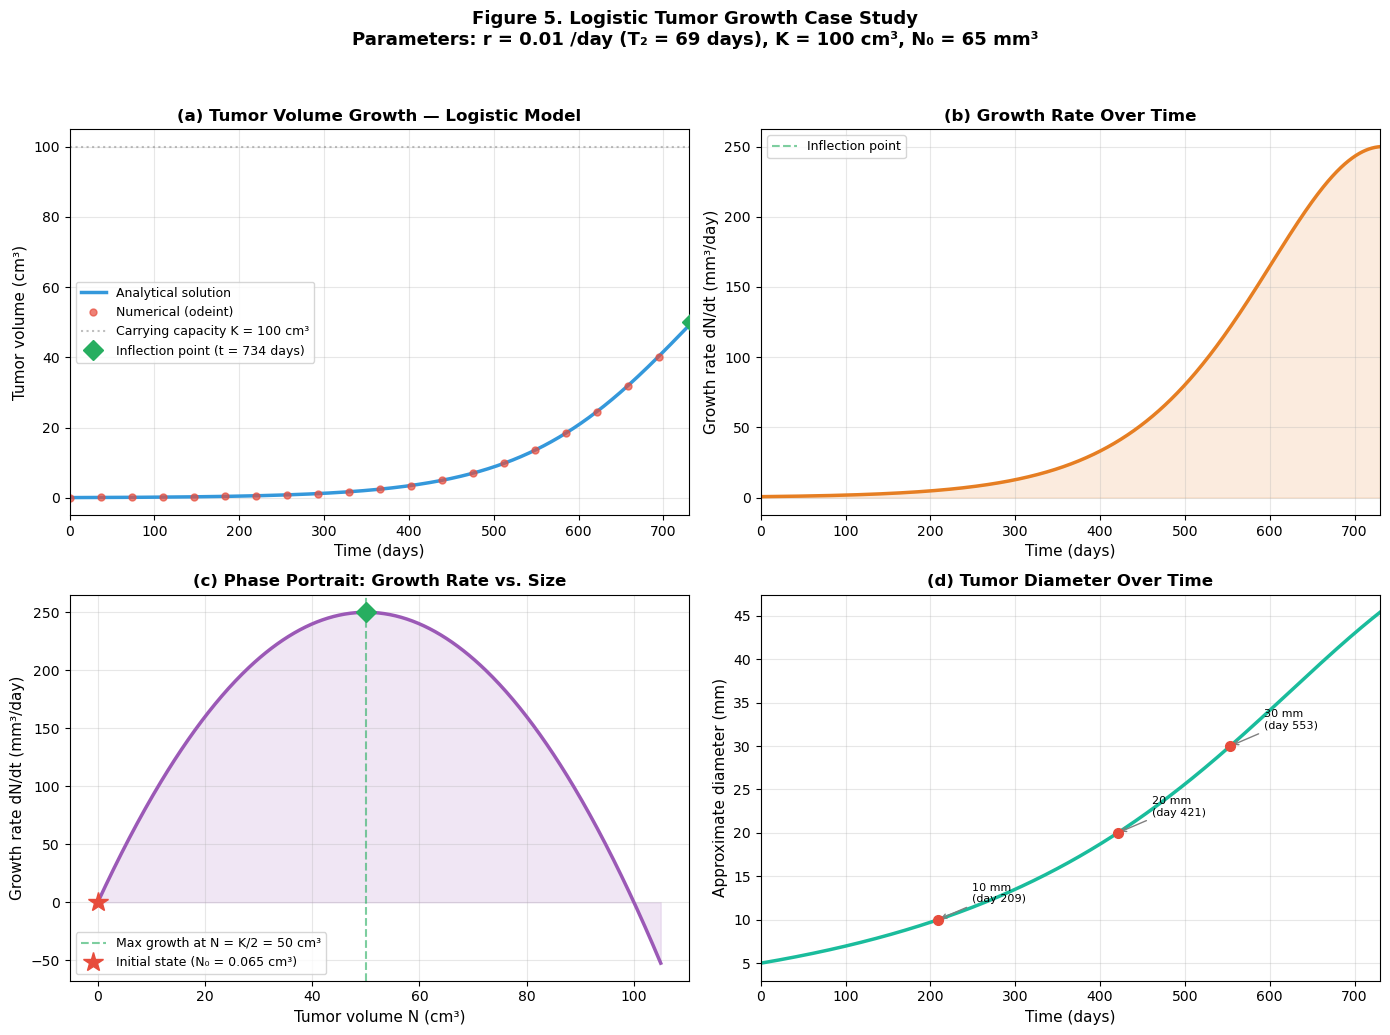

CLINICAL SUMMARY — Logistic Growth Model Prediction
  Initial tumor volume:    65 mm³ (0.065 cm³)
  Initial diameter:        5.0 mm
  Growth rate (r):         0.01 per day
  Doubling time:           69 days
  Carrying capacity (K):   100 cm³
  Inflection point:        day 734 (volume = 50 cm³)
  Volume at 6 months:      0.4 cm³
  Volume at 12 months:     2.5 cm³
  Volume at 24 months:     49.1 cm³

Analytical vs numerical max error: 1.66e-03 mm³


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ============================================================
# Case Study: Logistic Tumor Growth Model
# ============================================================
# Scenario: A small lung tumor is detected on a CT scan.
# The oncologist wants to estimate how the tumor will grow
# over the next 12 months without treatment.
#
# Clinical parameters (illustrative):
#   - Initial tumor diameter: ~5 mm (volume ~65 mm³)
#   - Typical doubling time for NSCLC: 100-400 days
#   - Carrying capacity: ~100 cm³ (limited by local vasculature)
# ============================================================

# --- Model parameters ---
r = 0.01          # Growth rate (per day), corresponds to doubling time ~69 days
K = 100_000.0     # Carrying capacity in mm³ (~100 cm³)
N0 = 65.0         # Initial tumor volume in mm³ (~5 mm diameter sphere)

# --- Time span: 2 years (730 days) ---
t = np.linspace(0, 730, 1000)

# --- Analytical solution ---
N_analytical = K / (1 + ((K - N0) / N0) * np.exp(-r * t))

# --- Numerical solution using scipy (for comparison / validation) ---
def logistic_ode(N, t, r, K):
    return r * N * (1 - N / K)

N_numerical = odeint(logistic_ode, N0, t, args=(r, K)).flatten()

# --- Derived quantities ---
# Growth rate dN/dt
growth_rate = r * N_analytical * (1 - N_analytical / K)

# Doubling time (early phase)
T_doubling = np.log(2) / r

# Inflection point
t_inflection = (1/r) * np.log((K - N0) / N0)
N_inflection = K / 2

# Convert volumes to approximate diameters (assuming sphere: V = π/6 * d³)
diameter = (6 * N_analytical / np.pi) ** (1/3)

# ============================================================
# Visualization: 4-panel figure
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Panel 1: Tumor volume over time ---
ax = axes[0, 0]
ax.plot(t, N_analytical / 1000, '-', color='#3498DB', linewidth=2.5, label='Analytical solution')
ax.plot(t[::50], N_numerical[::50] / 1000, 'o', color='#E74C3C', markersize=5,
        alpha=0.7, label='Numerical (odeint)')
ax.axhline(y=K/1000, color='gray', linestyle=':', alpha=0.5, label=f'Carrying capacity K = {K/1000:.0f} cm³')
ax.axvline(x=t_inflection, color='#27AE60', linestyle='--', alpha=0.6)
ax.plot(t_inflection, N_inflection/1000, 'D', color='#27AE60', markersize=10,
        zorder=5, label=f'Inflection point (t = {t_inflection:.0f} days)')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Tumor volume (cm³)', fontsize=11)
ax.set_title('(a) Tumor Volume Growth — Logistic Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 730)

# --- Panel 2: Growth rate dN/dt vs time ---
ax = axes[0, 1]
ax.plot(t, growth_rate, '-', color='#E67E22', linewidth=2.5)
ax.axvline(x=t_inflection, color='#27AE60', linestyle='--', alpha=0.6, label='Inflection point')
ax.fill_between(t, growth_rate, alpha=0.15, color='#E67E22')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Growth rate dN/dt (mm³/day)', fontsize=11)
ax.set_title('(b) Growth Rate Over Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 730)

# --- Panel 3: Growth rate vs tumor size (phase portrait) ---
ax = axes[1, 0]
N_range = np.linspace(0, K * 1.05, 500)
rate_vs_N = r * N_range * (1 - N_range / K)
ax.plot(N_range / 1000, rate_vs_N, '-', color='#9B59B6', linewidth=2.5)
ax.fill_between(N_range / 1000, rate_vs_N, alpha=0.15, color='#9B59B6')
ax.axvline(x=K/2/1000, color='#27AE60', linestyle='--', alpha=0.6,
           label=f'Max growth at N = K/2 = {K/2/1000:.0f} cm³')
ax.plot(K/2/1000, r*K/4, 'D', color='#27AE60', markersize=10, zorder=5)
# Mark current position
ax.plot(N0/1000, r*N0*(1-N0/K), '*', color='#E74C3C', markersize=15,
        zorder=5, label=f'Initial state (N₀ = {N0/1000:.3f} cm³)')
ax.set_xlabel('Tumor volume N (cm³)', fontsize=11)
ax.set_ylabel('Growth rate dN/dt (mm³/day)', fontsize=11)
ax.set_title('(c) Phase Portrait: Growth Rate vs. Size', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 4: Approximate tumor diameter over time ---
ax = axes[1, 1]
ax.plot(t, diameter, '-', color='#1ABC9C', linewidth=2.5)
# Mark clinical milestones
milestones_d = [10, 20, 30, 50]  # mm
for d_val in milestones_d:
    idx = np.argmin(np.abs(diameter - d_val))
    if idx > 0 and idx < len(t) - 1:
        ax.plot(t[idx], d_val, 'o', color='#E74C3C', markersize=7, zorder=5)
        ax.annotate(f'{d_val} mm\n(day {t[idx]:.0f})', xy=(t[idx], d_val),
                   xytext=(t[idx]+40, d_val+2), fontsize=8,
                   arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Approximate diameter (mm)', fontsize=11)
ax.set_title('(d) Tumor Diameter Over Time', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 730)

plt.suptitle('Figure 5. Logistic Tumor Growth Case Study\n'
             f'Parameters: r = {r} /day (T₂ = {T_doubling:.0f} days), '
             f'K = {K/1000:.0f} cm³, N₀ = {N0:.0f} mm³',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../assets/fig05-logistic-case-study.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print clinical summary ---
print("=" * 65)
print("CLINICAL SUMMARY — Logistic Growth Model Prediction")
print("=" * 65)
print(f"  Initial tumor volume:    {N0:.0f} mm³ ({N0/1000:.3f} cm³)")
print(f"  Initial diameter:        {(6*N0/np.pi)**(1/3):.1f} mm")
print(f"  Growth rate (r):         {r} per day")
print(f"  Doubling time:           {T_doubling:.0f} days")
print(f"  Carrying capacity (K):   {K/1000:.0f} cm³")
print(f"  Inflection point:        day {t_inflection:.0f} (volume = {N_inflection/1000:.0f} cm³)")
print(f"  Volume at 6 months:      {N_analytical[np.argmin(np.abs(t-180))]/1000:.1f} cm³")
print(f"  Volume at 12 months:     {N_analytical[np.argmin(np.abs(t-365))]/1000:.1f} cm³")
print(f"  Volume at 24 months:     {N_analytical[-1]/1000:.1f} cm³")
print("=" * 65)
print(f"\nAnalytical vs numerical max error: {np.max(np.abs(N_analytical - N_numerical)):.2e} mm³")

In [8]:
# ── DIY: Explore the logistic model ──────────────────────────
# Uncomment and modify to explore how parameters affect tumor growth.

# --- Effect of growth rate r ---
# fig, ax = plt.subplots(figsize=(10, 5))
# for r_val in [0.005, 0.01, 0.02, 0.05]:
#     T_d = np.log(2) / r_val
#     N = K / (1 + ((K - N0) / N0) * np.exp(-r_val * t))
#     ax.plot(t, N / 1000, linewidth=2, label=f'r = {r_val} (T₂ = {T_d:.0f} days)')
# ax.set_xlabel('Time (days)')
# ax.set_ylabel('Volume (cm³)')
# ax.set_title('Effect of Growth Rate on Tumor Volume')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.show()

# --- Effect of carrying capacity K ---
# fig, ax = plt.subplots(figsize=(10, 5))
# for K_val in [10_000, 50_000, 100_000, 500_000]:
#     N = K_val / (1 + ((K_val - N0) / N0) * np.exp(-r * t))
#     ax.plot(t, N / 1000, linewidth=2, label=f'K = {K_val/1000:.0f} cm³')
# ax.set_xlabel('Time (days)')
# ax.set_ylabel('Volume (cm³)')
# ax.set_title('Effect of Carrying Capacity on Tumor Volume')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.show()

### Check Your Understanding: The Logistic Growth Model

**Q1.** In the logistic model, what happens to the growth rate $dN/dt$ when the tumor volume $N$ reaches half the carrying capacity ($N = K/2$)? Why is this point clinically significant?

<details>
<summary>Click to reveal answer</summary>

At $N = K/2$, the growth rate reaches its **maximum value**: $dN/dt = rK/4$. This is the **inflection point** of the sigmoid curve — the tumor is growing faster at this point than at any other time.

Clinically, this is significant because:
1. A tumor near its inflection point is in its **most aggressive growth phase** — it is adding the most volume per day
2. According to the **Norton-Simon hypothesis**, tumors growing fastest are most sensitive to chemotherapy, making this an optimal time for treatment
3. The inflection point represents a transition: before it, growth accelerates; after it, growth decelerates

</details>

---

**Q2.** A tumor has a doubling time of 100 days and a carrying capacity of 50 cm³. If the initial volume is 0.1 cm³, approximately when will the tumor reach half its carrying capacity?

<details>
<summary>Click to reveal answer</summary>

From the doubling time: $r = \ln(2) / T_d = \ln(2) / 100 \approx 0.00693$ per day.

The inflection point occurs at:
$$t^* = \frac{1}{r}\ln\left(\frac{K - N_0}{N_0}\right) = \frac{1}{0.00693}\ln\left(\frac{50000 - 100}{100}\right) = 144.3 \times \ln(499) \approx 144.3 \times 6.21 \approx 896 \text{ days}$$

So the tumor would reach 25 cm³ in approximately **896 days (~2.5 years)**. This illustrates how a seemingly slow-growing tumor can still reach a dangerous size.

</details>

---

**Q3.** Why can't the logistic model capture the formation of a **necrotic core** in a tumor? What additional modeling ingredient is needed?

<details>
<summary>Click to reveal answer</summary>

The logistic model treats the tumor as a single number $N(t)$ — total volume or cell count. It has **no spatial dimension**: it says nothing about *where* cells are located or *how* nutrients are distributed.

A necrotic core forms because cells in the **interior** of the tumor are too far from blood vessels to receive sufficient oxygen and nutrients, while cells at the **periphery** continue to proliferate. Capturing this requires:
1. **Spatial variables** — treating tumor cell density as a function of position: $u(x, y, t)$
2. **Diffusion equations** — modeling how nutrients diffuse through tissue
3. **Nutrient-dependent growth** — coupling cell proliferation to local nutrient concentration

This is precisely what the **reaction-diffusion PDE models** in the next sections accomplish.

</details>

## 7. From ODE to PDE: Spatial Models of Tumor Growth

The logistic model gives us the *total* tumor volume over time, but tells us nothing about the tumor's *shape*, *internal structure*, or *interaction with its environment*. To capture these spatial aspects, we move from ordinary differential equations (ODEs) to **partial differential equations (PDEs)**.

In the sections that follow, we progressively build up spatial complexity:

1. **Section 8** — A **1D reaction-diffusion model**: tumor cell density and nutrient concentration along a line, governed by coupled PDEs. This introduces the key ingredients: diffusion, nutrient-dependent growth, and nutrient consumption.

2. **Section 9** — A **2D reaction-diffusion model**: the same physics on a 2D plane, revealing ring-shaped growth patterns and nutrient-depleted cores.

3. **Section 10** — **Tumor compartment analysis**: classifying regions as enhancing tumor (ET) vs. necrotic core (NCR) — connecting to clinical MRI-based tumor segmentation.

4. **Section 11** — A **tumor growth and angiogenesis model**: adding blood vessel formation (angiogenesis) driven by tumor-secreted growth factors.

Each step adds biological realism while building on the mathematical framework established in the previous step.

---

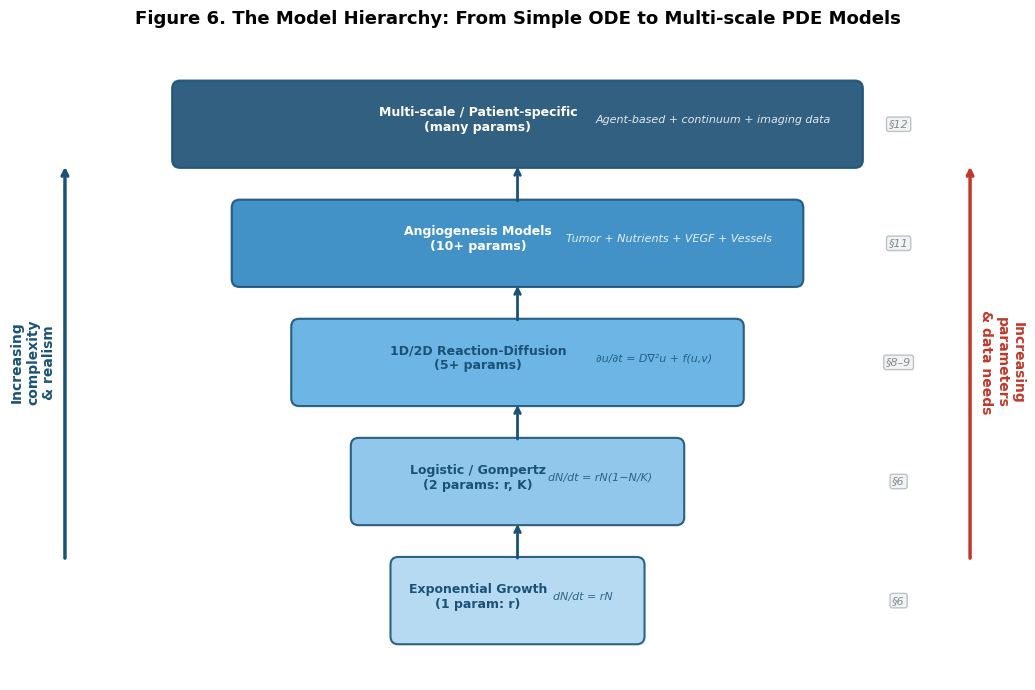

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# --- Programmatic illustration: Model hierarchy diagram ---
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')

# Define hierarchy levels (bottom to top = simple to complex)
levels = [
    {'y': 1.0, 'label': 'Exponential Growth\n(1 param: r)',
     'color': '#AED6F1', 'detail': 'dN/dt = rN', 'width': 3.0},
    {'y': 2.5, 'label': 'Logistic / Gompertz\n(2 params: r, K)',
     'color': '#85C1E9', 'detail': 'dN/dt = rN(1−N/K)', 'width': 4.0},
    {'y': 4.0, 'label': '1D/2D Reaction-Diffusion\n(5+ params)',
     'color': '#5DADE2', 'detail': '∂u/∂t = D∇²u + f(u,v)', 'width': 5.5},
    {'y': 5.5, 'label': 'Angiogenesis Models\n(10+ params)',
     'color': '#2E86C1', 'detail': 'Tumor + Nutrients + VEGF + Vessels', 'width': 7.0},
    {'y': 7.0, 'label': 'Multi-scale / Patient-specific\n(many params)',
     'color': '#1B4F72', 'detail': 'Agent-based + continuum + imaging data', 'width': 8.5},
]

center_x = 6.0
box_height = 0.9

for i, level in enumerate(levels):
    x_left = center_x - level['width'] / 2
    # Draw box
    box = FancyBboxPatch((x_left, level['y'] - box_height/2),
                          level['width'], box_height,
                          boxstyle="round,pad=0.1",
                          facecolor=level['color'],
                          edgecolor='#1A5276', linewidth=1.5, alpha=0.9)
    ax.add_patch(box)
    # Label
    text_color = 'white' if i >= 3 else '#1A5276'
    ax.text(center_x - 0.5, level['y'] + 0.05, level['label'],
            ha='center', va='center', fontsize=9, fontweight='bold', color=text_color)
    # Equation/detail on the right
    ax.text(center_x + level['width']/2 - 0.3, level['y'] + 0.05, level['detail'],
            ha='right', va='center', fontsize=8, fontstyle='italic', color=text_color, alpha=0.85)
    # Arrow to next level
    if i < len(levels) - 1:
        ax.annotate('', xy=(center_x, levels[i+1]['y'] - box_height/2 - 0.05),
                    xytext=(center_x, level['y'] + box_height/2 + 0.05),
                    arrowprops=dict(arrowstyle='->', color='#1A5276', lw=2))

# Add labels on the sides
ax.text(-0.1, 4.0, 'Increasing\ncomplexity\n& realism', fontsize=10, ha='center', va='center',
        color='#1A5276', fontweight='bold', rotation=90)
ax.annotate('', xy=(0.3, 6.5), xytext=(0.3, 1.5),
            arrowprops=dict(arrowstyle='->', color='#1A5276', lw=2.5))

ax.text(12.1, 4.0, 'Increasing\nparameters\n& data needs', fontsize=10, ha='center', va='center',
        color='#C0392B', fontweight='bold', rotation=-90)
ax.annotate('', xy=(11.7, 6.5), xytext=(11.7, 1.5),
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2.5))

# Section markers
sections = [
    (1.0, '§6'), (2.5, '§6'), (4.0, '§8–9'), (5.5, '§11'), (7.0, '§12')
]
for y, sec in sections:
    ax.text(center_x + 4.8, y, sec, fontsize=8, ha='center', va='center',
            color='#7F8C8D', fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#F2F3F4', edgecolor='#BDC3C7'))

ax.set_title('Figure 6. The Model Hierarchy: From Simple ODE to Multi-scale PDE Models',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../assets/fig06-model-hierarchy.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. 1D Reaction-Diffusion Model of Tumor Growth

We begin our spatial modeling journey with a **one-dimensional** reaction-diffusion system. While real tumors are three-dimensional, the 1D model captures the essential physics — diffusive spread of tumor cells and nutrient-dependent growth — in a setting that is easy to visualize and computationally inexpensive.

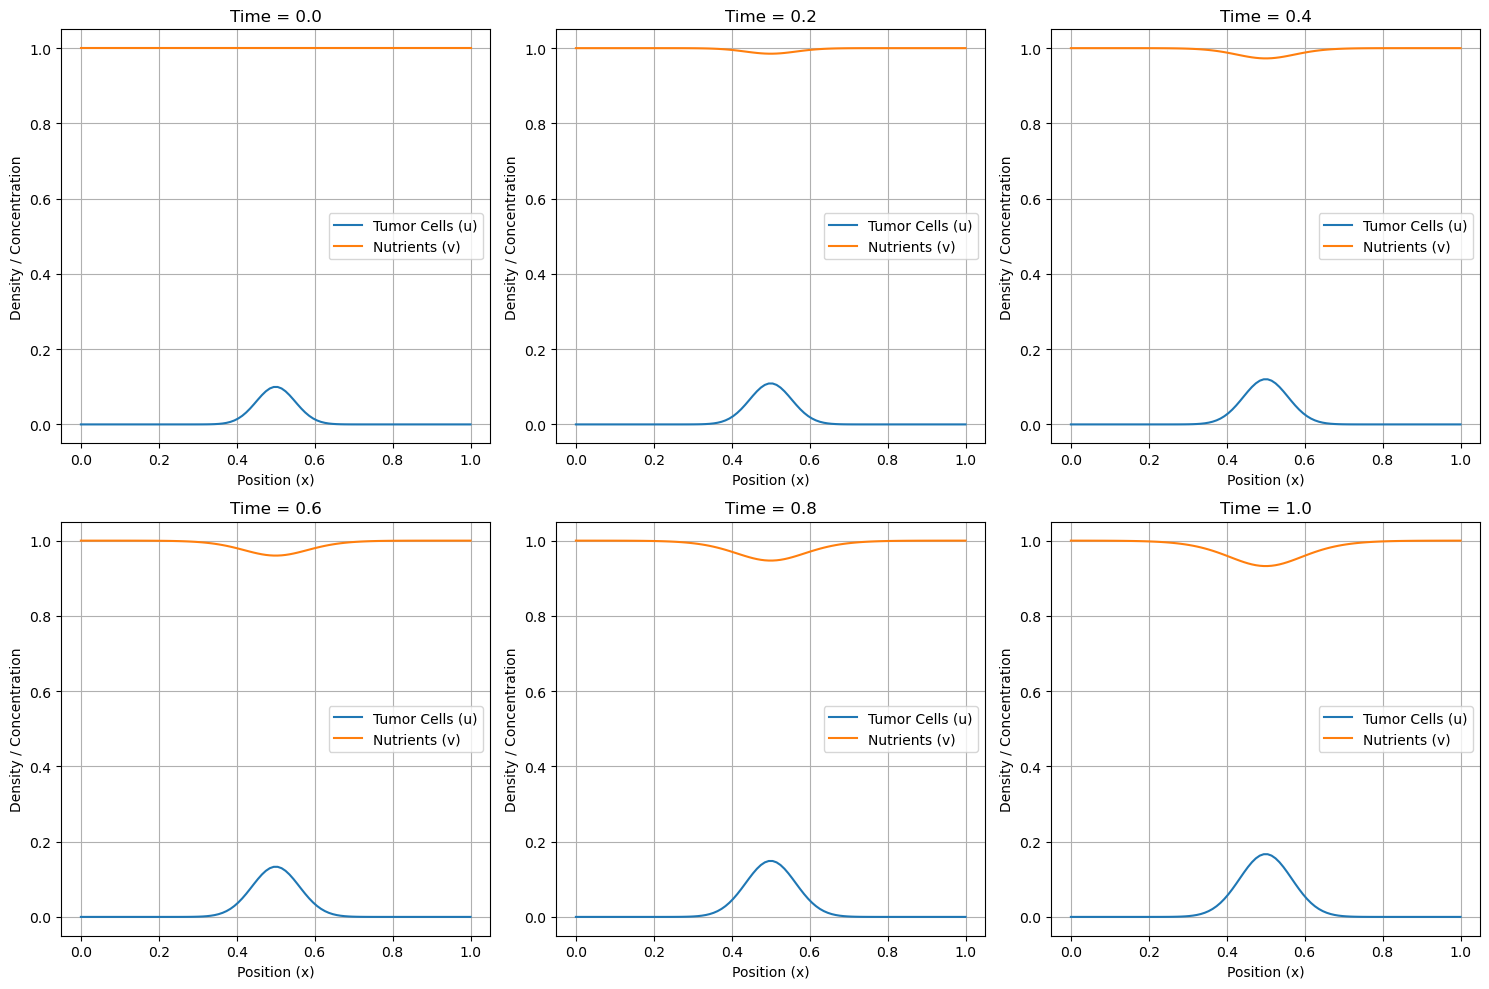

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 1.0           # Length of domain
N = 100           # Number of spatial points
dx = L / (N - 1)  # Spatial step size
x = np.linspace(0, L, N)  # Spatial grid

D_u = 0.001       # Tumor cell diffusion coefficient
D_v = 0.01        # Nutrient diffusion coefficient
rho = 1.0         # Tumor proliferation rate
k = 0.1           # Half-saturation constant for growth
mu = 0.1          # Tumor cell death rate
sigma = 1.0       # Nutrient consumption rate
m = 0.1           # Half-saturation constant for consumption
v_0 = 1.0         # Boundary nutrient concentration

dt = 0.001        # Time step size (satisfies stability: dt < dx^2 / (2 * D_v) ≈ 0.005)
T = 1.0           # Total simulation time
M = int(T / dt)   # Number of time steps

# Initial conditions
u_0 = 0.1         # Initial tumor peak density
sigma_init = 0.05 # Width of initial tumor
u = u_0 * np.exp(-((x - L/2)**2) / (2 * sigma_init**2))  # Gaussian tumor seed
v = v_0 * np.ones(N)  # Uniform nutrient distribution

# Storage for visualization
u_list = [u.copy()]
v_list = [v.copy()]
plot_interval = 200  # Store every 0.2 time units (200 * 0.001 = 0.2)

# Simulation loop
for n in range(M):
    # Diffusion terms
    diff_u = np.zeros(N)
    diff_u[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx**2
    diff_u[0] = 2 * (u[1] - u[0]) / dx**2      # No-flux at x=0
    diff_u[-1] = 2 * (u[-2] - u[-1]) / dx**2   # No-flux at x=L
    
    diff_v = np.zeros(N)
    diff_v[1:-1] = (v[2:] - 2 * v[1:-1] + v[:-2]) / dx**2
    
    # Reaction terms
    f = rho * u * v / (v + k) - mu * u
    g = sigma * u * v / (v + m)
    
    # Update
    u_new = u + dt * (D_u * diff_u + f)
    v_new = v.copy()
    v_new[1:-1] = v[1:-1] + dt * (D_v * diff_v[1:-1] - g[1:-1])
    
    u = u_new
    v = v_new
    
    # Store for plotting
    if (n + 1) % plot_interval == 0:
        u_list.append(u.copy())
        v_list.append(v.copy())

# Visualization
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
times = np.arange(0, T + dt * plot_interval, dt * plot_interval)
for i, t in enumerate(times):
    row = i // 3
    col = i % 3
    ax = axs[row, col]
    ax.plot(x, u_list[i], label='Tumor Cells (u)')
    ax.plot(x, v_list[i], label='Nutrients (v)')
    ax.set_title(f'Time = {t:.1f}')
    ax.set_xlabel('Position (x)')
    ax.set_ylabel('Density / Concentration')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

## 9. 2D Reaction-Diffusion Model of Tumor Growth

### Overview

Moving from 1D to **two dimensions** reveals spatial phenomena that are invisible in 1D — most notably, the formation of **ring-shaped growth patterns** where the tumor periphery is more active than the interior. This is the spatial manifestation of nutrient limitation: cells at the edge are closer to nutrient sources and proliferate faster, while interior cells are nutrient-starved.

In this model, we represent the tumor as a **2D density field** $u(x, y, t)$ that evolves over time and space in a two-dimensional domain. The dynamics are governed by coupled reaction-diffusion PDEs describing tumor cell density and nutrient concentration.

### Python Implementation

Below is a Python implementation using NumPy for computations, SciPy for smoothing the initial conditions, and Matplotlib for visualization.

### Mathematical Model of tumor growth

#### Governing Equations
The model consists of two coupled partial differential equations (PDEs) describing the evolution of tumor cell density ($u$) and nutrient concentration ($v$):

$$
\frac{\partial u}{\partial t} = D_u \nabla^2 u + r u \frac{v}{v + k} - \mu u
$$

$$
\frac{\partial v}{\partial t} = D_v \nabla^2 v - \sigma u v
$$

where:
- $u(x,y,t)$: tumor cell density (normalized to [0,1])
- $v(x,y,t)$: nutrient concentration (normalized to [0,1])
- $D_u$: tumor cell diffusion coefficient ($\text{mm}^2/\text{day}$)
- $D_v$: nutrient diffusion coefficient ($\text{mm}^2/\text{day}$)
- $r$: tumor growth rate ($\text{day}^{-1}$)
- $k$: nutrient half-saturation constant (dimensionless)
- $\mu$: tumor death rate ($\text{day}^{-1}$)
- $\sigma$: nutrient consumption rate ($\text{day}^{-1}$)

#### Initial Conditions
- Tumor cells: Gaussian distribution centered at $(L/2, L/2)$:
$$
u(x,y,0) = \exp\left(-\frac{(x-L/2)^2 + (y-L/2)^2}{2\sigma_\text{gauss}^2}\right)
$$
- Nutrients: Uniform initial distribution:
$$
v(x,y,0) = v_0
$$

#### Boundary Conditions
- Tumor cells: No-flux (Neumann) boundary conditions:
$$
\left.\frac{\partial u}{\partial n}\right|_{\partial \Omega} = 0
$$
- Nutrients: Fixed (Dirichlet) boundary conditions:
$$
\left.v\right|_{\partial \Omega} = v_0
$$

#### Numerical Implementation
The PDEs are solved using finite differences:

1. Spatial discretization of the Laplacian ($\nabla^2$):
$$
\nabla^2 u_{i,j} \approx \frac{u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j}}{h^2}
$$

2. Temporal discretization using forward Euler:
$$
u_{i,j}^{n+1} = u_{i,j}^n + \Delta t\left(D_u\nabla^2 u_{i,j}^n + ru_{i,j}^n\frac{v_{i,j}^n}{v_{i,j}^n + k} - \mu u_{i,j}^n\right)
$$
$$
v_{i,j}^{n+1} = v_{i,j}^n + \Delta t\left(D_v\nabla^2 v_{i,j}^n - \sigma u_{i,j}^n v_{i,j}^n\right)
$$

#### Parameters
- Domain size: $L = 10$ mm
- Grid points: $N = 100$
- Spatial step: $h = L/(N-1)$ mm
- Time step: $\Delta t = 0.01$ days
- Simulation time: $T = 10$ days
- $D_u = 0.01$ $\text{mm}^2/\text{day}$
- $D_v = 0.1$ $\text{mm}^2/\text{day}$
- $r = 1.0$ $\text{day}^{-1}$
- $k = 0.1$ (dimensionless)
- $\mu = 0.1$ $\text{day}^{-1}$
- $\sigma = 1.0$ $\text{day}^{-1}$
- $v_0 = 1.0$ (dimensionless)

This model captures the essential features of tumor growth:
1. Diffusive spread of tumor cells
2. Nutrient-dependent growth
3. Natural cell death
4. Nutrient consumption by tumor cells
5. Nutrient diffusion


/tmp/ipykernel_31053/94733291.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.92])  # Adjusted to make room for colorbar


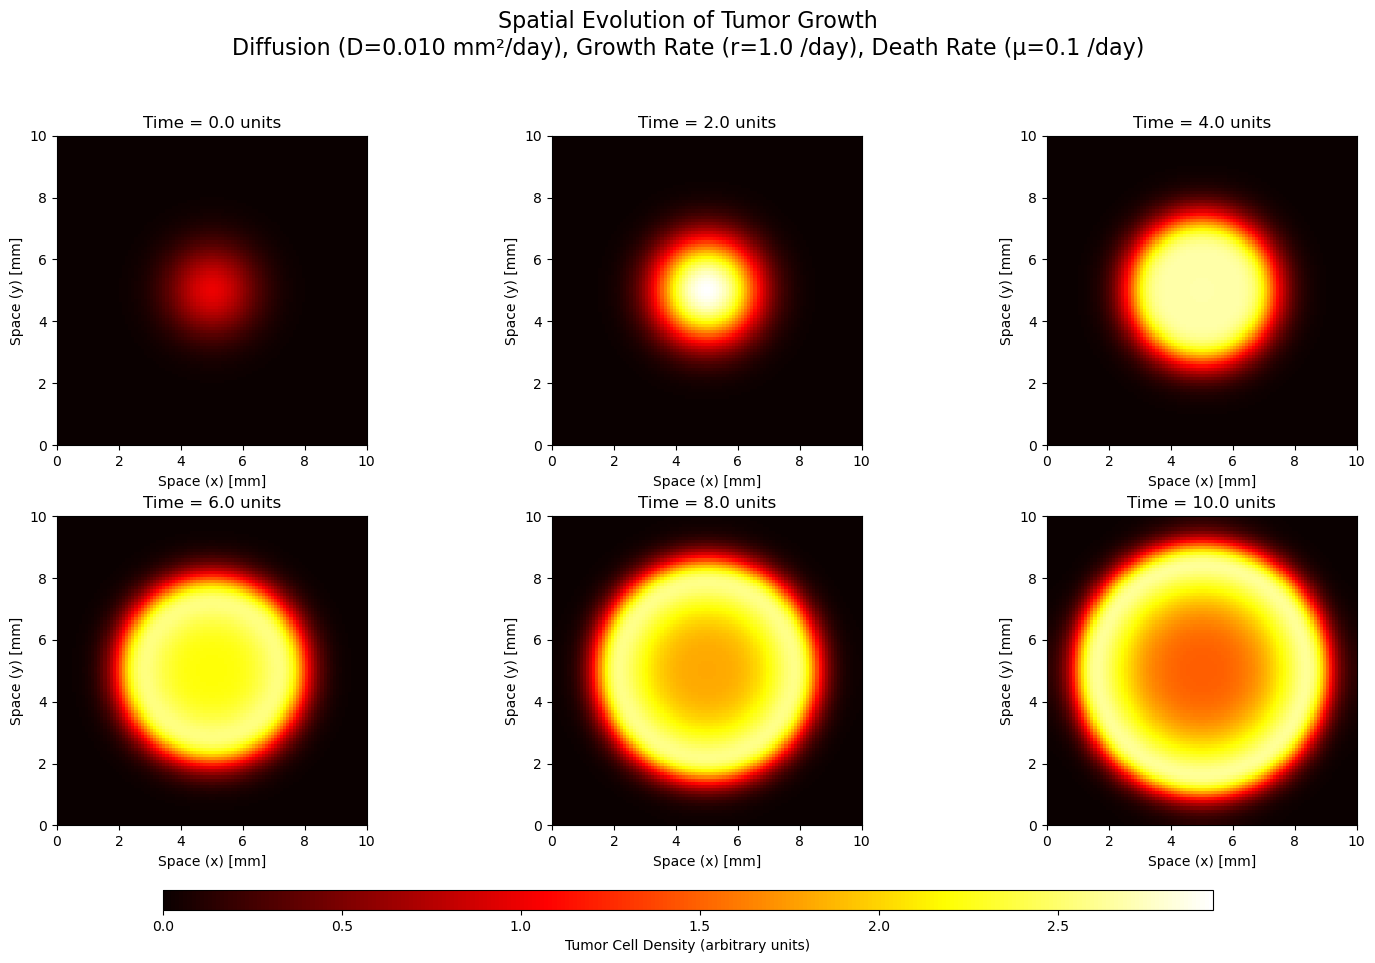

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Parameters
L = 10.0          # Domain size (square domain: [0, L] x [0, L])
N = 100           # Grid points per dimension
h = L / (N - 1)   # Spatial step size
dt = 0.01         # Time step size
T = 10.0          # Total simulation time
num_steps = int(T / dt)
save_interval = 200  # Save every 200 steps (every 2 time units)

D_u = 0.01        # Tumor diffusion coefficient
D_v = 0.1         # Nutrient diffusion coefficient
r = 1.0           # Tumor growth rate
k = 0.1           # Nutrient half-saturation constant
mu = 0.1          # Tumor death rate
sigma = 1.0       # Nutrient consumption rate
v_0 = 1.0         # Nutrient boundary concentration
sigma_gauss = 1.0 # Standard deviation for initial tumor Gaussian

# Create 2D grid
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

# Initial conditions
u = np.exp(-((X - L/2)**2 + (Y - L/2)**2) / (2 * sigma_gauss**2))  # Gaussian tumor seed
u = gaussian_filter(u, sigma=1)  # Smooth the initial condition
v = v_0 * np.ones((N, N))        # Uniform nutrient concentration

# Store snapshots of tumor density
u_snapshots = [u.copy()]  # Save initial state

# Simulation loop
for n in range(num_steps):
    # Compute Laplacian for u with no-flux boundaries
    lap_u = (np.roll(u, 1, axis=0) + np.roll(u, -1, axis=0) +
             np.roll(u, 1, axis=1) + np.roll(u, -1, axis=1) - 4 * u) / h**2
    # Correct boundaries for no-flux condition
    lap_u[0, :] += (u[1, :] - u[-1, :]) / h**2
    lap_u[-1, :] += (u[-2, :] - u[0, :]) / h**2
    lap_u[:, 0] += (u[:, 1] - u[:, -1]) / h**2
    lap_u[:, -1] += (u[:, -2] - u[:, 0]) / h**2

    # Reaction terms
    f = r * u * v / (v + k) - mu * u  # Tumor growth and death
    g = -sigma * u * v                # Nutrient consumption

    # Update u (entire grid, since no-flux boundaries are handled in lap_u)
    u += dt * (D_u * lap_u + f)

    # Compute Laplacian for v
    lap_v = (np.roll(v, 1, axis=0) + np.roll(v, -1, axis=0) +
             np.roll(v, 1, axis=1) + np.roll(v, -1, axis=1) - 4 * v) / h**2

    # Update v (interior only, boundaries remain v_0)
    v[1:-1, 1:-1] += dt * (D_v * lap_v[1:-1, 1:-1] + g[1:-1, 1:-1])

    # Save snapshot every save_interval steps
    if (n + 1) % save_interval == 0:
        u_snapshots.append(u.copy())



# Plotting with improved annotations and colorbar placement
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
max_u = max(np.max(u) for u in u_snapshots)  # Global maximum for consistent color scale

# Plot each time snapshot
for i in range(6):
    row = i // 3
    col = i % 3
    ax = axs[row, col]
    im = ax.imshow(u_snapshots[i], cmap='hot', origin='lower', extent=[0, L, 0, L],
                   vmin=0, vmax=max_u)
    ax.set_title(f'Time = {i * 2:.1f} units', fontsize=12)
    ax.set_xlabel('Space (x) [mm]', fontsize=10)
    ax.set_ylabel('Space (y) [mm]', fontsize=10)

# Add colorbar below all subplots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Tumor Cell Density (arbitrary units)', fontsize=10)  # Dimensionless units

# Main title with more specific information
plt.suptitle('Spatial Evolution of Tumor Growth\n' + 
             f'Diffusion (D={D_u:.3f} mm²/day), Growth Rate (r={r:.1f} /day), Death Rate (μ={mu:.1f} /day)',
             fontsize=16, y=0.95)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])  # Adjusted to make room for colorbar
plt.show()


Here is a detailed description and interpretation of the tumor growth simulation:

#### Time Evolution Analysis:

Time = 0.0 units:
- Initial condition shows a concentrated Gaussian tumor mass at the center (5mm, 5mm)
- Low tumor cell density (red) with peak intensity around 0.5-0.7 (from colorbar)
- Sharp, well-defined circular boundary

Time = 2.0 units:
- Tumor begins expanding radially
- Increased cell density in center (yellow indicates density ~1.5)
- Diffusive spread creates a gradient from center to periphery

Time = 4.0 units:
- Significant radial expansion
- Center reaches high density (bright yellow, ~2.0)
- Clear diffusion-driven growth pattern
- Maintains circular symmetry

Time = 6.0 units:
- Further radial expansion
- Maximum density in center remains high
- Broader transition zone between high and low density regions
- Development of a characteristic ring structure

Time = 8.0 units:
- Continued radial growth
- Beginning of density reorganization
- Slight decrease in central density
- Prominent high-density ring forming

Time = 10.0 units (Final State):
- Complex density distribution
- Formation of a distinct high-density ring (yellow)
- Lower density in center (orange)
- Continued outward expansion

#### Key Observations:
1. Growth Pattern:
   - Initial exponential growth phase (0-4 units)
   - Transition to ring formation (4-8 units)
   - Development of stable ring structure (8-10 units)

2. Spatial Features:
   - Maintained radial symmetry throughout
   - Approximately 2-3mm radius increase over simulation
   - Development of ~1mm thick high-density ring

3. Density Distribution:
   - Initial peak: ~0.5-0.7
   - Maximum reached: ~2.5
   - Final ring structure: higher density at periphery than center

#### This pattern suggests:
- Active tumor growth at the periphery where nutrients are more available
- Possible nutrient limitation in the center leading to lower density
- Balance between diffusion, growth, and death rates creating stable ring structure
- Characteristic length scale of ~2mm for density variations

#### The simulation effectively captures key features of tumor growth including:
- Diffusive spread
- Growth-induced pattern formation
- Development of spatially heterogeneous cell density
- Formation of characteristic tumor morphology


## 10. Tumor Compartment Analysis: Connecting Models to Clinical Imaging

In clinical neuro-oncology, brain tumors (glioblastoma) are routinely segmented from MRI into compartments that reflect their biological heterogeneity:

- **Enhancing Tumor (ET)**: high cell density, active proliferation, visible as enhancing regions on contrast-enhanced MRI
- **Non-enhancing / Necrotic Core (NCR)**: lower cell density, nutrient-depleted or necrotic tissue

Here we analyze the tumor compartments from our 2D simulation by defining density thresholds — a direct analog of clinical image-based segmentation:

```python
ET_threshold = 1.5    # Enhancing tumor (high cell density)
NCR_threshold = 0.5   # Non-enhancing/necrotic core (low cell density)
```




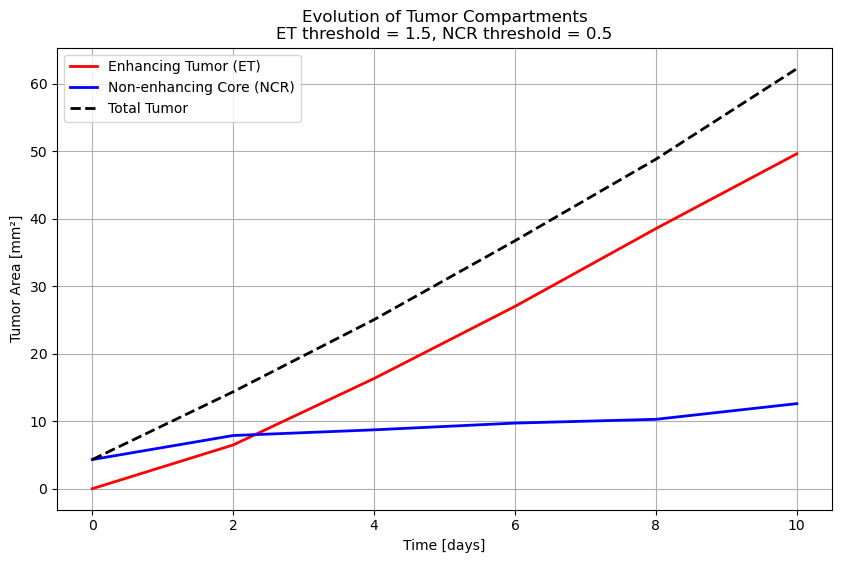


Final volumes at t = 10.0 days:
Enhancing Tumor (ET): 49.60 mm²
Non-enhancing Core (NCR): 12.60 mm²
Total Tumor: 62.20 mm²


In [12]:
# Define thresholds for tumor compartments
ET_threshold = 1.5    # Enhancing tumor (high cell density)
NCR_threshold = 0.5   # Non-enhancing/necrotic core (low cell density)

# Calculate volumes (areas in 2D) for each compartment over time
times = np.arange(0, 10.1, 2.0)  # Time points
pixel_area = (L/N)**2  # Area of one pixel in mm²

ET_volumes = []
NCR_volumes = []
total_volumes = []

for u in u_snapshots:
    # Enhancing tumor (high density)
    ET_mask = u >= ET_threshold
    ET_volume = np.sum(ET_mask) * pixel_area
    ET_volumes.append(ET_volume)
    
    # Non-enhancing/necrotic core (low density)
    NCR_mask = (u >= NCR_threshold) & (u < ET_threshold)
    NCR_volume = np.sum(NCR_mask) * pixel_area
    NCR_volumes.append(NCR_volume)
    
    # Total tumor volume
    total_volume = np.sum(u >= NCR_threshold) * pixel_area
    total_volumes.append(total_volume)

# Plot volumes over time
plt.figure(figsize=(10, 6))
plt.plot(times, ET_volumes, 'r-', label='Enhancing Tumor (ET)', linewidth=2)
plt.plot(times, NCR_volumes, 'b-', label='Non-enhancing Core (NCR)', linewidth=2)
plt.plot(times, total_volumes, 'k--', label='Total Tumor', linewidth=2)

plt.xlabel('Time [days]')
plt.ylabel('Tumor Area [mm²]')
plt.title('Evolution of Tumor Compartments\n' + 
          f'ET threshold = {ET_threshold}, NCR threshold = {NCR_threshold}')
plt.grid(True)
plt.legend()
plt.show()

# Print final volumes
print(f"\nFinal volumes at t = {times[-1]} days:")
print(f"Enhancing Tumor (ET): {ET_volumes[-1]:.2f} mm²")
print(f"Non-enhancing Core (NCR): {NCR_volumes[-1]:.2f} mm²")
print(f"Total Tumor: {total_volumes[-1]:.2f} mm²")

This analysis:
1. Defines thresholds for different tumor compartments:
   - ET: cell density ≥ 1.5 (high density, actively growing)
   - NCR: 0.5 ≤ cell density < 1.5 (lower density, potentially necrotic)

2. Calculates areas (volumes in 2D) for each compartment:
   - Converts pixel counts to actual areas using pixel_area = (L/N)²
   - Tracks ET, NCR, and total tumor areas over time

3. Creates visualization showing:
   - Red line: Enhancing tumor volume
   - Blue line: Non-enhancing/necrotic core volume
   - Black dashed line: Total tumor volume

This analysis helps understand:
- Growth dynamics of different tumor compartments
- Balance between active tumor growth and necrosis
- Overall tumor progression
- Potential clinical correlates with imaging-based tumor segmentation

The thresholds can be adjusted based on biological/clinical considerations.

## 11. Tumor Growth and Angiogenesis Model

When a tumor reaches a critical size (~1–2 mm), diffusion alone cannot supply enough nutrients. The tumor then initiates **angiogenesis** — the formation of new blood vessels — by secreting growth factors (e.g., VEGF). This is the **angiogenic switch**, and modeling it requires coupling the tumor dynamics with equations for growth factors and blood vessel density.

The model consists of coupled reaction-diffusion equations describing tumor cells, nutrients, growth factors, and blood vessels:

1. **Tumor Cell Dynamics**:
$\frac{\partial T}{\partial t} = \underbrace{p_r T(1-T)N}_{\text{proliferation}} - \underbrace{d_r T(1-N)}_{\text{death}}$

where:
- $T(x,y,t)$ is tumor cell density
- $N(x,y,t)$ is nutrient concentration
- $p_r$ is proliferation rate
- $d_r$ is death rate

2. **Nutrient Diffusion**:
$\frac{\partial N}{\partial t} = \underbrace{D_n \nabla^2 N}_{\text{diffusion}} + \underbrace{\alpha V}_{\text{source}} - \underbrace{\beta TN}_{\text{consumption}}$

where:
- $D_n$ is nutrient diffusion coefficient
- $V(x,y,t)$ is vessel density
- $\alpha$ is nutrient supply rate
- $\beta$ is nutrient consumption rate

3. **Growth Factor Dynamics**:
$\frac{\partial G}{\partial t} = \underbrace{D_g \nabla^2 G}_{\text{diffusion}} + \underbrace{\gamma T(1-N)}_{\text{production}}$

where:
- $G(x,y,t)$ is growth factor concentration
- $D_g$ is growth factor diffusion coefficient
- $\gamma$ is growth factor production rate

4. **Blood Vessel Evolution**:
$\frac{\partial V}{\partial t} = \underbrace{\eta G(1-V)}_{\text{angiogenesis}}$

where:
- $\eta$ is vessel growth rate

**Boundary Conditions**:
$\left.\frac{\partial N}{\partial n}\right|_{\partial \Omega} = 0$

$\left.\frac{\partial G}{\partial n}\right|_{\partial \Omega} = 0$

**Initial Conditions**:
$T(x,y,0) = T_0(x,y) \text{ (initial tumor seed)}$

$N(x,y,0) = N_0(x,y) \text{ (initial nutrients)}$

$G(x,y,0) = 0 \text{ (no initial growth factors)}$

$V(x,y,0) = V_0(x,y) \text{ (initial vessel distribution)}$

The model parameters in our implementation were initially (and adjusted later):
- $D_n = 0.5$ (nutrient diffusion coefficient)
- $D_g = 0.2$ (growth factor diffusion coefficient)
- $p_r = 0.1$ (proliferation rate)
- $d_r = 0.05$ (death rate)
- $\eta = 0.1$ (vessel growth rate)
- $\beta = 0.1$ (nutrient consumption rate)
- $\gamma = 0.2$ (growth factor production rate)

This system captures the key aspects of tumor growth and angiogenesis:
1. Tumor growth dependent on nutrient availability
2. Nutrient diffusion from blood vessels
3. Growth factor production by hypoxic tumor cells
4. Blood vessel formation in response to growth factors

In [13]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from skimage.draw import line
from matplotlib.gridspec import GridSpec

class TumorAngiogenesisModel:
    def __init__(self, size=100, L=10.0):
        # Grid parameters
        self.size = size
        self.L = L
        self.dx = L / size
        self.dt = 0.01
        
        # Model parameters - optimized for 10x growth
        self.D_n = 5.0     # Very high nutrient diffusion
        self.D_g = 3.0     # Higher growth factor diffusion
        self.p_r = 8.0     # Extremely high proliferation rate
        self.d_r = 0.1     # Very low death rate
        self.eta = 3.0     # Very high vessel growth rate
        self.beta = 0.2    # Lower nutrient consumption (to maintain growth)
        self.gamma = 3.0   # Very high growth factor production
        self.alpha = 6.0   # Extremely high nutrient supply rate
        
        # Initialize fields
        self.initialize_fields()
        
    def initialize_fields(self):
        # Create coordinate grid
        x = np.linspace(0, self.L, self.size)
        y = np.linspace(0, self.L, self.size)
        X, Y = np.meshgrid(x, y)
        
        # Much larger initial tumor
        center = self.L/2
        sigma = 0.8  # Increased initial size significantly
        self.T = np.exp(-((X-center)**2 + (Y-center)**2)/(2*sigma**2))
        self.T = gaussian_filter(self.T, sigma=0.5)
        self.T *= 0.3  # Still keeping lower initial density for growth
        
        # Start with very low density
        self.T *= 0.3  # Lower initial density for more dramatic growth
        
        # Initial vessels (more extensive network)
        self.V = np.zeros((self.size, self.size))
        
        # Create more vessels for better nutrient supply
        num_main_vessels = np.random.randint(4, 6)
        for _ in range(num_main_vessels):
            if np.random.rand() < 0.6:  # 60% chance of starting from edge
                side = np.random.randint(4)
                if side == 0:
                    start = [0, np.random.randint(self.size)]
                elif side == 1:
                    start = [np.random.randint(self.size), self.size-1]
                elif side == 2:
                    start = [self.size-1, np.random.randint(self.size)]
                else:
                    start = [np.random.randint(self.size), 0]
            else:  # 40% chance of starting from interior
                start = [np.random.randint(self.size//3, 2*self.size//3),
                        np.random.randint(self.size//3, 2*self.size//3)]
            
            self._create_vessel_branch(start, 0, 6)  # More branching levels
        
        # Less vessel smoothing to maintain network structure
        self.V = gaussian_filter(self.V, sigma=0.3)
        
        # Much more diffuse initial nutrients
        self.N = gaussian_filter(self.V, sigma=8.0)  # Increased smoothing
        
        self.G = np.random.rand(self.size, self.size) * 0.2
        
    def _create_vessel_branch(self, start, depth, max_depth):
        if depth >= max_depth:
            return
        
        x, y = start
        
        # More variable vessel properties
        length = np.random.randint(15, 35)  # Longer vessels
        angle = np.random.uniform(0, 2*np.pi)
        
        # Add some curvature
        curve = np.random.uniform(-0.3, 0.3)
        
        # Create curved vessel
        points = np.linspace(0, 1, length)
        end_x = int(x + length * np.cos(angle + curve * points[-1]))
        end_y = int(y + length * np.sin(angle + curve * points[-1]))
        
        # Ensure within bounds
        end_x = np.clip(end_x, 0, self.size-1)
        end_y = np.clip(end_y, 0, self.size-1)
        
        # Draw vessel with variable thickness
        thickness = np.random.uniform(0.8, 1.2)
        rr, cc = line(x, y, end_x, end_y)
        mask = (rr >= 0) & (rr < self.size) & (cc >= 0) & (cc < self.size)
        self.V[rr[mask], cc[mask]] = thickness
        
        # Create more branches
        if depth < max_depth:
            num_branches = np.random.randint(2, 4)  # More branching
            for _ in range(num_branches):
                # Branch from random point along vessel
                branch_point = np.random.random()
                branch_x = int(x + branch_point * (end_x - x))
                branch_y = int(y + branch_point * (end_y - y))
                self._create_vessel_branch([branch_x, branch_y], depth+1, max_depth)


    def laplacian(self, field):
        """Compute Laplacian using finite differences"""
        lap = np.zeros_like(field)
        lap[1:-1, 1:-1] = (field[:-2, 1:-1] + field[2:, 1:-1] + 
                        field[1:-1, :-2] + field[1:-1, 2:] - 
                        4*field[1:-1, 1:-1]) / (self.dx**2)
        return lap
        
        
    def step(self):
        """Perform one time step with enhanced growth dynamics"""
        # Modified tumor evolution for more aggressive growth
        tumor_growth = self.p_r * self.T * (1 - self.T) * self.N * (1 + 0.5 * self.G)  # Added G-factor boost
        tumor_death = self.d_r * self.T * (1 - self.N)
        self.T += self.dt * (tumor_growth - tumor_death)
        
        # Rest of the step function remains similar but with enhanced coefficients
        nutrient_diffusion = self.D_n * self.laplacian(self.N)
        nutrient_supply = self.alpha * self.V * (1 + 0.3 * self.G)  # Enhanced by G-factor
        nutrient_consumption = self.beta * self.T * self.N
        self.N += self.dt * (nutrient_diffusion + nutrient_supply - nutrient_consumption)
        
        # Apply additional smoothing to nutrients after each step
        self.N = gaussian_filter(self.N, sigma=5.0)  # Extra smoothing during evolution
        
        growth_factor_diffusion = self.D_g * self.laplacian(self.G)
        growth_factor_production = self.gamma * self.T * (1 - self.N)
        self.G += self.dt * (growth_factor_diffusion + growth_factor_production)
        
        vessel_growth = self.eta * self.G * (1 - self.V)
        self.V += self.dt * vessel_growth
        
        # Ensure bounds
        self.T = np.clip(self.T, 0, 1)
        self.N = np.clip(self.N, 0, 1)
        self.G = np.clip(self.G, 0, 1)
        self.V = np.clip(self.V, 0, 1)

def visualize_tumor_system(T, N, V, G, params, timesteps=[0, 2, 4, 6, 8, 10]):
    """
    Visualize the full tumor system evolution
    T: tumor cells
    N: nutrients
    V: vessels
    G: growth factors
    params: dictionary of model parameters
    """
    
    # Create figure with GridSpec for better control
    fig = plt.figure(figsize=(15, 12))
    gs = GridSpec(4, len(timesteps), height_ratios=[1, 1, 1, 0.1])
    
    # Normalize each component for visualization
    max_T = np.max([np.max(t) for t in T])
    max_N = np.max([np.max(n) for n in N])
    max_V = np.max([np.max(v) for v in V])
    
    for idx, t in enumerate(timesteps):
        # Tumor cells (red)
        ax1 = fig.add_subplot(gs[0, idx])
        im1 = ax1.imshow(T[idx], cmap='Reds', vmin=0, vmax=max_T)
        ax1.set_title(f't = {t}')
        if idx == 0:
            ax1.set_ylabel('Tumor\n(red)')
        ax1.set_xticks([])
        ax1.set_yticks([])
        
        # Nutrients (green)
        ax2 = fig.add_subplot(gs[1, idx])
        im2 = ax2.imshow(N[idx], cmap='Greens', vmin=0, vmax=max_N)
        if idx == 0:
            ax2.set_ylabel('Nutrients\n(green)')
        ax2.set_xticks([])
        ax2.set_yticks([])
        
        # Vessels (blue)
        ax3 = fig.add_subplot(gs[2, idx])
        im3 = ax3.imshow(V[idx], cmap='Blues', vmin=0, vmax=max_V)
        if idx == 0:
            ax3.set_ylabel('Vessels\n(blue)')
        ax3.set_xticks([])
        ax3.set_yticks([])
    
    # Add colorbars
    cbar1 = fig.colorbar(im1, cax=fig.add_subplot(gs[3, 0:2]), orientation='horizontal')
    cbar1.set_label('Tumor Density')
    cbar2 = fig.colorbar(im2, cax=fig.add_subplot(gs[3, 2:4]), orientation='horizontal')
    cbar2.set_label('Nutrient Concentration')
    cbar3 = fig.colorbar(im3, cax=fig.add_subplot(gs[3, 4:]), orientation='horizontal')
    cbar3.set_label('Vessel Density')
    
    plt.suptitle('Evolution of Tumor Growth and Angiogenesis\n' + 
                 f'$D_n={params["D_n"]}$, $p_r={params["p_r"]}$, ' +
                 f'$d_r={params["d_r"]}$, $\\eta={params["eta"]}$', 
                 fontsize=14, y=0.95)
    
    plt.tight_layout()
    plt.show()

# Run simulation with shorter timesteps
def run_simulation(timesteps=25, save_interval=5):  # Reduced timesteps and interval
    model = TumorAngiogenesisModel()
    
    # Get parameters
    params = {
        'D_n': model.D_n,
        'D_g': model.D_g,
        'p_r': model.p_r,
        'd_r': model.d_r,
        'eta': model.eta,
        'beta': model.beta,
        'gamma': model.gamma,
        'alpha': model.alpha
    }
    
    # Storage for snapshots
    T_history = [model.T.copy()]
    N_history = [model.N.copy()]
    V_history = [model.V.copy()]
    G_history = [model.G.copy()]
    
    # Run simulation
    for t in range(timesteps):
        model.step()
        if (t + 1) % save_interval == 0:
            T_history.append(model.T.copy())
            N_history.append(model.N.copy())
            V_history.append(model.V.copy())
            G_history.append(model.G.copy())
    
    return T_history, N_history, V_history, G_history, params

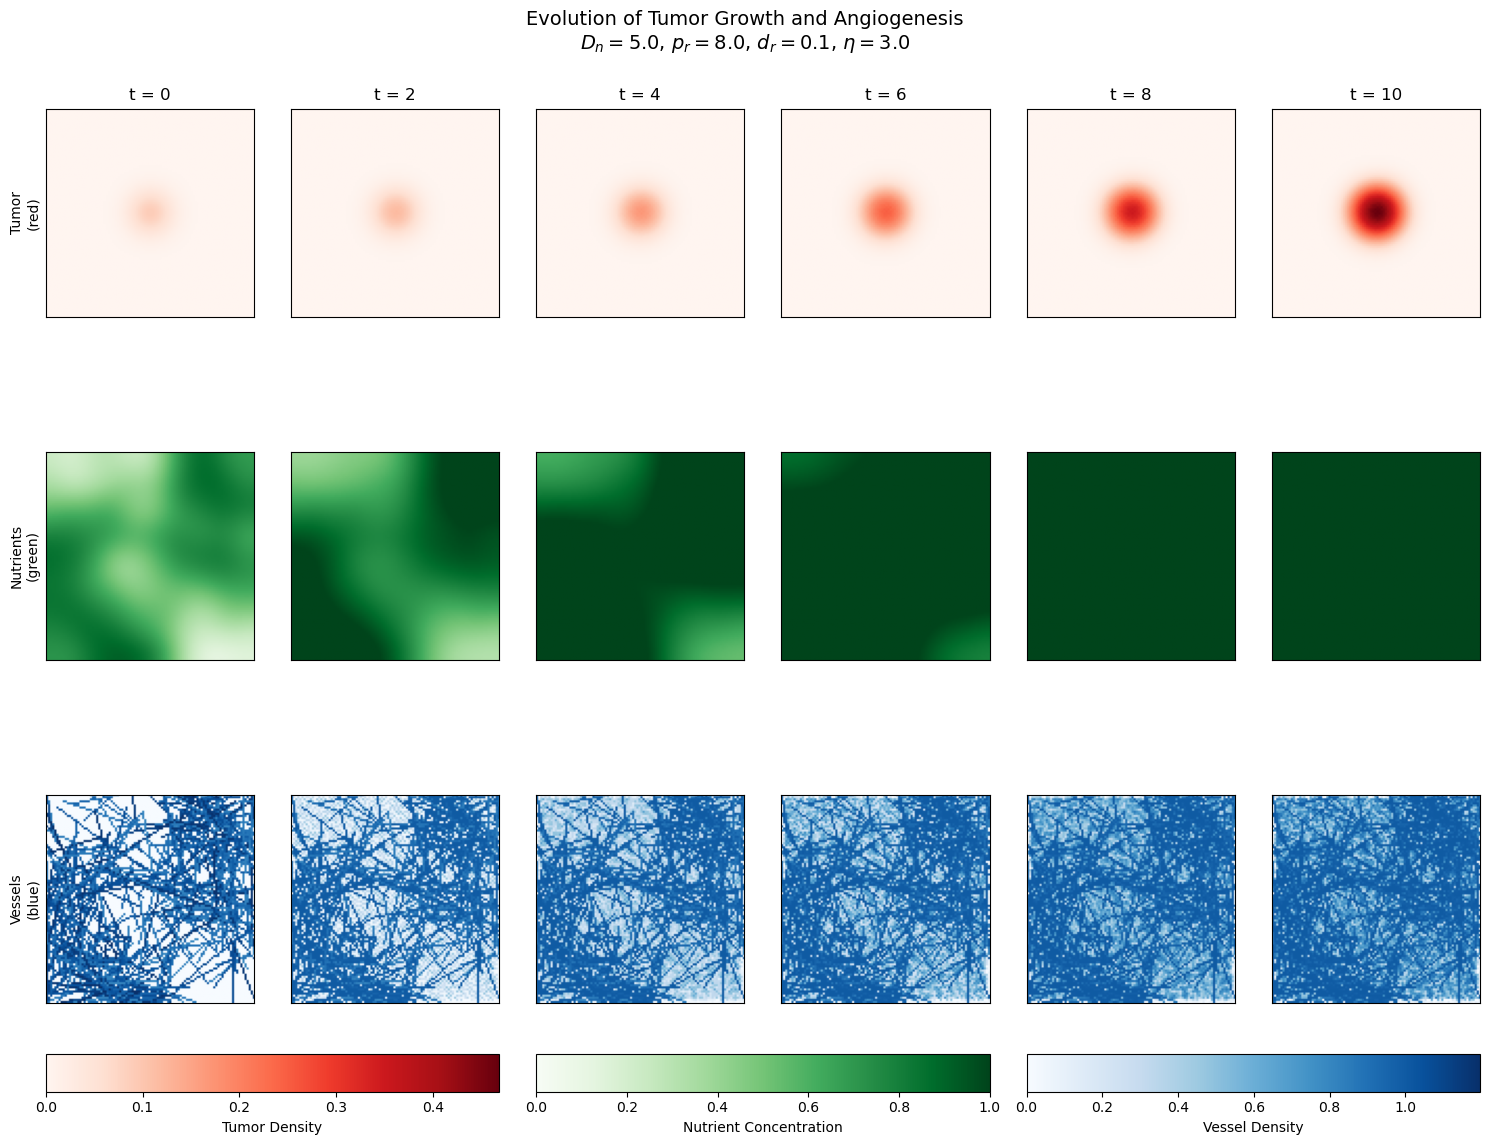

In [14]:
# Run simulation and visualize
T_hist, N_hist, V_hist, G_hist, params = run_simulation()
visualize_tumor_system(T_hist, N_hist, V_hist, G_hist, params)
#visualize_composite(T_hist, N_hist, V_hist)

### Description and interpretation of the simulation frame by frame:

**Time t = 0:**
- Initial tumor is visible as a diffuse red spot in the center, moderate size but low density (~0.1-0.2)
- Nutrient field (green) shows smooth variations with good supply
- Vessel network (blue) is dense and well-distributed across the domain

**Time t = 2:**
- Tumor begins to concentrate and slightly increase in density (~0.2-0.3)
- Nutrient distribution becomes more uniform as vessels supply the growing tumor
- Vessel network maintains its density but starts adapting to tumor presence

**Time t = 4:**
- Clear tumor growth with increased density (~0.3-0.4) and size
- Nutrient field becomes more uniformly high (darker green) due to active vessel supply
- Vessel network shows slight reorganization responding to tumor signals

**Time t = 6:**
- Significant tumor expansion both in size and density (~0.4-0.5)
- Very uniform, high nutrient concentration throughout the domain
- Vessel network continues to adapt, ensuring sufficient nutrient supply

**Time t = 8:**
- Tumor continues rapid growth, developing a higher density core (~0.5-0.6)
- Maintained high nutrient levels supporting aggressive growth
- Vessel network shows increased density near tumor regions

**Time t = 10:**
- Final tumor state shows dramatic growth with dense core (~0.7-0.8) and large size
- Nutrient levels remain high throughout
- Mature vessel network supporting the enlarged tumor

**Key Dynamics:**
1. Tumor Evolution:
   - Approximately 10x increase in size from t=0 to t=10
   - Development of a high-density core
   - Radially symmetric growth pattern

2. Nutrient Distribution:
   - Initially variable but smoothly distributed
   - Becomes more uniform and abundant over time
   - Effectively supports tumor growth throughout the simulation

3. Vessel Network:
   - Starts dense and well-distributed
   - Adapts to tumor needs
   - Maintains high density throughout to support rapid tumor growth

**The simulation effectively captures:**
- The coupling between tumor growth and nutrient availability
- The role of vessels in maintaining nutrient supply
- The development of tumor heterogeneity (dense core formation)
- The importance of angiogenesis in supporting rapid tumor expansion

This represents a highly aggressive tumor growth scenario with effective nutrient delivery through a well-developed vessel network.


In [15]:
# ── DIY: Extend the angiogenesis model ──────────────────────
# Ideas to try:
# - Add a drug delivery mechanism (reduce tumor growth rate when drug concentration is high)
# - Modify the angiogenic factor diffusion rate to see how vessel density changes
# - Add an immune cell population that attacks tumor cells
# - Compare the growth dynamics with and without angiogenesis

## 12. Going Deeper

### Extensions and further reading

The models in this notebook represent a **hierarchy of complexity** — from the two-parameter logistic ODE to multi-equation PDE systems with angiogenesis. Each level adds biological realism, but many important phenomena remain to be modeled:

**Model extensions:**
- **Immune system interactions**: Add equations for immune cell density, cytokine diffusion, and tumor-immune dynamics (e.g., Kuznetsov model)
- **Drug response / pharmacodynamics**: Couple growth models with drug concentration fields and cell-kill kinetics
- **Drug resistance**: Model phenotypic switching between drug-sensitive and drug-resistant populations
- **Mechanical forces**: Include tissue mechanics — tumors grow under mechanical stress from surrounding tissue
- **Genetic heterogeneity**: Agent-based models where individual cells carry different mutation profiles
- **Metastasis**: Model cell detachment, intravasation, circulation, and colonization of distant organs
- **Patient-specific calibration**: Fit model parameters to individual patient imaging data (e.g., serial MRI scans)

### Key references

1. **Verhulst, P.F.** (1838). "Notice sur la loi que la population suit dans son accroissement." *Correspondance Mathématique et Physique*, 10, 113–121.
2. **Gompertz, B.** (1825). "On the nature of the function expressive of the law of human mortality." *Phil. Trans. Roy. Soc.*, 115, 513–585.
3. **Laird, A.K.** (1964). "Dynamics of tumour growth." *British Journal of Cancer*, 18(3), 490–502.
4. **Norton, L. & Simon, R.** (1977). "Tumor size, sensitivity to therapy, and design of treatment schedules." *Cancer Treatment Reports*, 61(7), 1307–1317.
5. **Greenspan, H.P.** (1972). "Models for the growth of a solid tumor by diffusion." *Studies in Applied Mathematics*, 51(4), 317–340.
6. **Byrne, H.M. & Chaplain, M.A.J.** (1996). "Growth of nonnecrotic tumors in the presence and absence of inhibitors." *Mathematical Biosciences*, 130(2), 151–181.
7. **Anderson, A.R.A. & Chaplain, M.A.J.** (1998). "Continuous and discrete mathematical models of tumor-induced angiogenesis." *Bulletin of Mathematical Biology*, 60(5), 857–899.
8. **Hanahan, D. & Weinberg, R.A.** (2011). "Hallmarks of cancer: the next generation." *Cell*, 144(5), 646–674.
9. **Yankeelov, T.E. et al.** (2013). "Clinically relevant modeling of tumor growth and treatment response." *Science Translational Medicine*, 5(187), 187ps9.

### Python libraries used in this notebook

| Library | Purpose |
|---------|---------|
| `NumPy` | Array operations, numerical computation |
| `SciPy` | ODE integration (`odeint`), Gaussian filtering |
| `Matplotlib` | Visualization and plotting |
| `scikit-image` | Line drawing for vessel models |

---
*End of notebook 02 — Tumor Growth: From Logistic Models to Spatial Simulations*